In [107]:
# Provides support for numerical computations and multi-dimensional arrays.
import numpy as np  

# Offers powerful data manipulation and analysis tools using DataFrames.
import pandas as pd  


# Enables creation of static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt  

# Allows custom colormap creation for matplotlib plots.
from matplotlib.colors import LinearSegmentedColormap  

# Simplifies statistical data visualization and integrates seamlessly with matplotlib.
import seaborn as sns  


# Facilitates creation of interactive visualizations and dashboards using Plotly.
import plotly.graph_objects as go  

# Offers high-level interface for creating interactive Plotly visualizations quickly.
import plotly.express as px  

# Provides tools for arranging multiple subplots in Plotly visualizations.
import plotly.subplots as sp  

# Simplifies the creation of complex subplot layouts.
from plotly.subplots import make_subplots  

# Enables detailed control of individual Plotly plot objects.
import plotly.graph_objs as go  


# Tools for encoding categorical variables.
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer  

# Provides scaling tools for normalizing features.
from sklearn.preprocessing import MinMaxScaler, StandardScaler  

# Function to compute mean absolute error for model evaluation.
from sklearn.metrics import mean_absolute_error  

# Performs Principal Component Analysis for dimensionality reduction.
from sklearn.decomposition import PCA  


# Offers utilities for generating random numbers and sequences.
import random  

# Provides functions for calculating statistical measures (mean, median, etc.).
import statistics

### Loading datasets

The code snippet loads `data_train` and `data_test` from: 


In [108]:
train_path = "data/output/00_data_understanding/data_test.csv"
test_path = "data/output/00_data_understanding/data_train.csv"

In [109]:
data_train = pd.read_csv(train_path)
data_test = pd.read_csv(test_path)

print("Datasets loaded successfully.")        # Prints a message if the datasets are loaded successfully.

Datasets loaded successfully.


# Plots

## World map `contryOfOrigins`

In [110]:
import pandas as pd
import plotly.express as px
from iso3166 import countries_by_alpha2  # Install via: pip install iso3166
import numpy as np

def load_iso_country_codes(file_path):
    """
    Carica i codici paese ISO-2 da un file .txt.

    Parametri:
    - file_path (str): Percorso al file .txt contenente i codici ISO.

    Ritorna:
    - set: Un set di codici paese ISO-2.
    """
    with open(file_path, 'r') as file:
        country_codes = {line.strip() for line in file if line.strip()}
    return country_codes

def convert_iso2_to_iso3(iso2_codes):
    """
    Converte i codici paese ISO-2 in ISO-3.

    Parametri:
    - iso2_codes (list): Una lista di codici paese ISO-2.

    Ritorna:
    - dict: Dizionario che mappa ISO-2 a ISO-3.
    """
    iso2_to_iso3 = {}
    for iso2 in iso2_codes:
        try:
            iso2_to_iso3[iso2] = countries_by_alpha2[iso2].alpha3
        except KeyError:
            iso2_to_iso3[iso2] = None  # Paesi non mappati
    return iso2_to_iso3

def create_world_map_from_dataset(dataset, iso_country_codes):
    """
    Genera una mappa mondiale che visualizza il numero di film per paese con scala logaritmica per i colori,
    ma mostra i valori originali nei tooltip e nella barra colori.

    Parametri:
    - dataset (pd.DataFrame): Dataset con colonne one-hot dei paesi.
    - iso_country_codes (set): Set di codici paese ISO-2 validi.

    Ritorna:
    - fig: Mappa coropletica di Plotly.
    - unrepresented_countries: DataFrame con paesi non rappresentati.
    """
    # Filtra le colonne relative ai paesi
    country_columns = [col for col in dataset.columns if col in iso_country_codes]

    # Somma i conteggi dei film per ogni paese
    country_counts = dataset[country_columns].sum().reset_index()
    country_counts.columns = ['Country', 'FilmCount']

    # Converte ISO-2 in ISO-3
    iso2_to_iso3 = convert_iso2_to_iso3(country_counts['Country'])
    country_counts['ISO3'] = country_counts['Country'].map(iso2_to_iso3)

    # Identifica i paesi non rappresentati
    unrepresented_countries = country_counts[country_counts['ISO3'].isna()]
    print("Paesi non rappresentati e righe corrispondenti:")
    print(unrepresented_countries[['Country', 'FilmCount']])

    # Filtra i paesi rappresentati
    country_counts = country_counts[country_counts['ISO3'].notna()]

    # Applica la scala logaritmica per i colori
    country_counts['LogFilmCount'] = np.log1p(country_counts['FilmCount'])  # log(1 + x)

    # Crea la mappa
    fig = px.choropleth(
        country_counts,
        locations="ISO3",  # Codici paese ISO-3
        locationmode="ISO-3",  # Modalità ISO-3
        color="LogFilmCount",  # Valori logaritmici per mappare i colori
        title="Numero di film per paese",
        color_continuous_scale="Blues",
        hover_data={"LogFilmCount": False, "FilmCount": True}  # Mostra i valori originali nei tooltip
    )

    # Modifica i tick nella barra colori per mostrare i valori originali
    fig.update_coloraxes(
        colorbar_tickvals=[np.log1p(x) for x in [1, 10, 100, 1000, 10000]],
        colorbar_ticktext=["1", "10", "100", "1k", "10k"]  # Etichette leggibili
    )

    # Layout aggiornato per migliore visualizzazione
    fig.update_layout(
        geo=dict(
            showframe=False,
            showcoastlines=True,
            projection_type='equirectangular'
        )
    )

    return fig, unrepresented_countries[['Country', 'FilmCount']]

In [111]:

# Carica i codici paese ISO
iso_country_codes = load_iso_country_codes('encoding_lists/countryOfOrigin.txt')

In [112]:

# Esempio d'uso con il dataset
fig_train, unrepresented_train = create_world_map_from_dataset(data_train, iso_country_codes)

# Mostra la mappa
fig_train.show()

Paesi non rappresentati e righe corrispondenti:
    Country  FilmCount
24     CSHH         22
25     CSXX          1
29     DDDE          9
97     SUHH         99
109     XKV          1
110     XWG         96
111     XYU         16
112    YUCS          2


In [113]:

# Esempio d'uso con il dataset
fig_test, unrepresented_train = create_world_map_from_dataset(data_test, iso_country_codes)

# Mostra la mappa
fig_test.show()

Paesi non rappresentati e righe corrispondenti:
    Country  FilmCount
28     CSHH         74
29     CSXX          3
33     DDDE         33
128    SUHH        238
146     XKV          1
147     XWG        243
148     XYU         53
149    YUCS          5


# Managing not recognized values

in `countryOfOrigin.txt` there are countries that are not recognized by ISO standard used for the function. In order to manage that we looked for these values and find which country and ISO code correspondent.

unrecognized_country_mapping = {
    'CSHH': 'Czechoslovakia',
    'CSXX': 'Serbia and Montenegro',
    'DDDE': 'East Germany',
    'SUHH': 'Soviet Union',
    'XKV': 'Kosovo',
    'XWG': 'West Germany',
    'XYU': 'Yugoslavia',
    'YUCS': 'Serbia and Montenegro'
}
These are country that doesn't exists when are analyzed in the dataset, so we decided to not care about it, but just show them.

/tmp/ipykernel_37498/2087070548.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




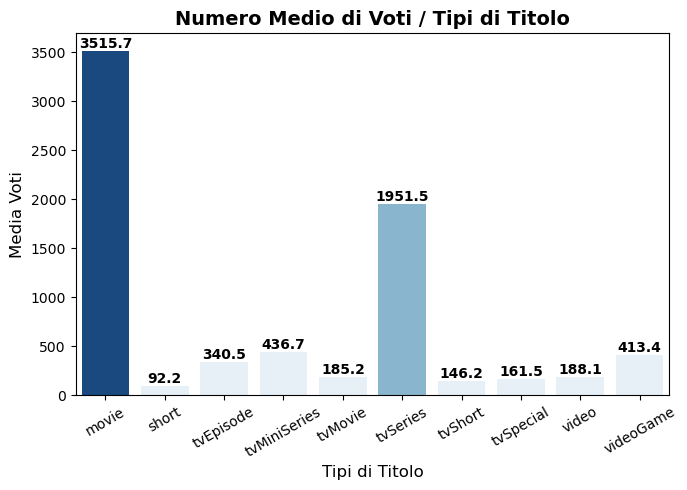

/tmp/ipykernel_37498/2087070548.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




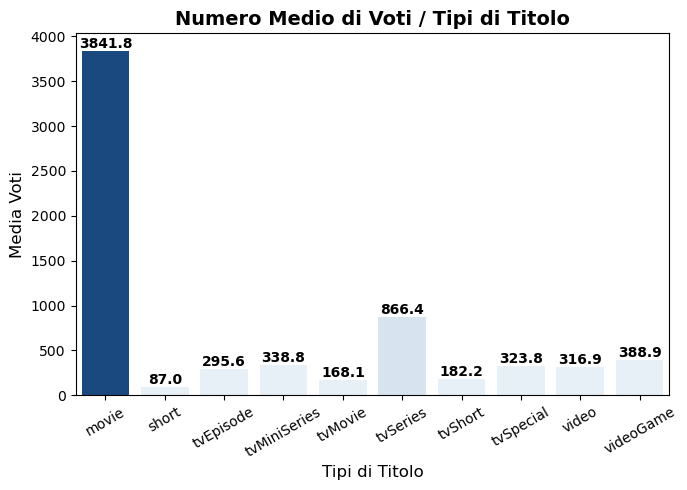

In [114]:

def generate_mean_votes_chart(data):
    if 'titleType' in data.columns and 'numVotes' in data.columns:
        votes_mean = data.groupby('titleType')['numVotes'].mean()
        
        # Normalizziamo i valori per assegnare il colore
        normalized_values = (votes_mean - votes_mean.min()) / (votes_mean.max() - votes_mean.min())
        
        # Creiamo la scala di colori usando la colormap 'Oranges'
        palette = sns.color_palette("Blues", len(votes_mean))
        color_map = [palette[int(norm * (len(palette) - 1))] for norm in normalized_values]
        
        # Impostiamo la dimensione del grafico
        plt.figure(figsize=(7, 5))
        
        # Creiamo il barplot con la scala di arancioni
        ax = sns.barplot(x=votes_mean.index, y=votes_mean.values, palette=color_map)
        
        # Aggiungiamo le etichette alle barre
        for i, value in enumerate(votes_mean.values):
            ax.text(i, value, f"{value:.1f}", ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')
        
        # Personalizziamo il grafico
        plt.xticks(rotation=30)
        plt.title('Numero Medio di Voti / Tipi di Titolo', fontsize=14, fontweight='bold')
        plt.ylabel('Media Voti', fontsize=12)
        plt.xlabel('Tipi di Titolo', fontsize=12)
        
        # Mostriamo il grafico
        plt.tight_layout()
        plt.show()
        
generate_mean_votes_chart(data_test)
generate_mean_votes_chart(data_train)

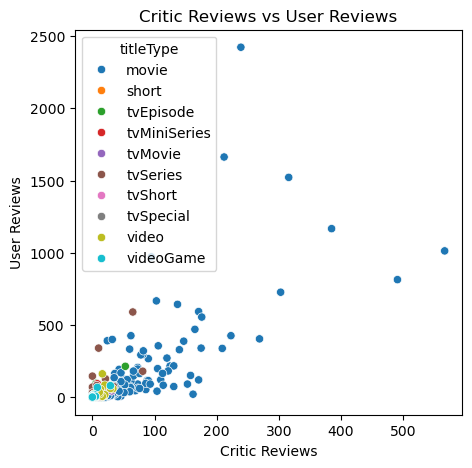

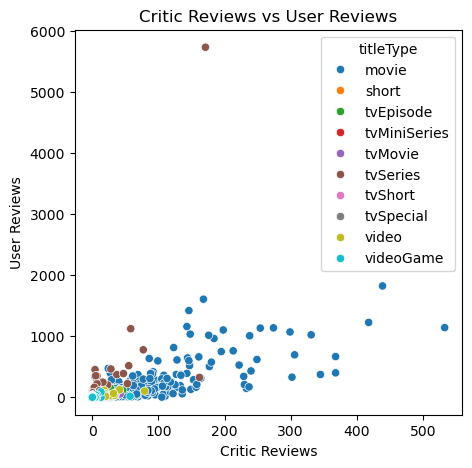

In [115]:

def generate_scatter_chart(data, x_col, y_col, hue_col='titleType', title=None, xlabel=None, ylabel=None, sort=False, color_map=None):
    if x_col in data.columns and y_col in data.columns:
        if sort and hue_col in data.columns:
            if data[hue_col].dtype.kind in 'biufc':  # Numeric types
                data = data.sort_values(by=hue_col, ascending=True)
            elif data[hue_col].dtype.kind == 'O':  # Object types (e.g., strings)
                data = data.sort_values(by=hue_col, key=lambda col: col.str.lower())

        # Define or use the color map
        if color_map is None:
            unique_hues = data[hue_col].unique()
            palette = sns.color_palette("tab10", len(unique_hues))
            color_map = dict(zip(unique_hues, palette))

        plt.figure(figsize=(5, 5))
        sns.scatterplot(x=x_col, y=y_col, data=data, hue=hue_col, palette=color_map)
        plt.title(title if title else f'{x_col} vs {y_col}')
        plt.xlabel(xlabel if xlabel else x_col)
        plt.ylabel(ylabel if ylabel else y_col)
        if hue_col in data.columns:
            plt.legend(title=hue_col)
        plt.show()
    else:
        raise ValueError(f"Columns {x_col} and/or {y_col} not found in the dataset.")


generate_scatter_chart(data_train, 'criticReviewsTotal', 'userReviewsTotal', 'titleType', 'Critic Reviews vs User Reviews', 'Critic Reviews', 'User Reviews', sort = True)
generate_scatter_chart(data_test, 'criticReviewsTotal', 'userReviewsTotal', 'titleType', 'Critic Reviews vs User Reviews', 'Critic Reviews', 'User Reviews', sort = True)

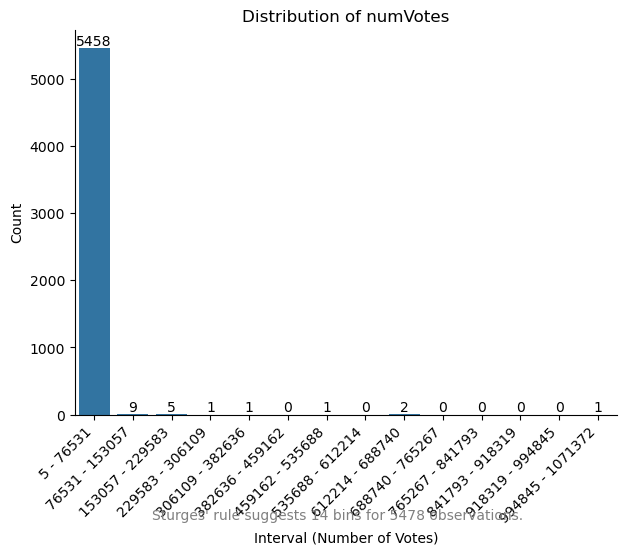

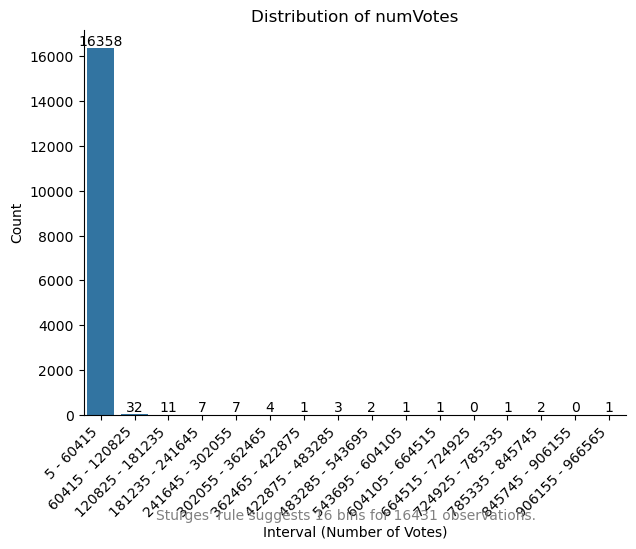

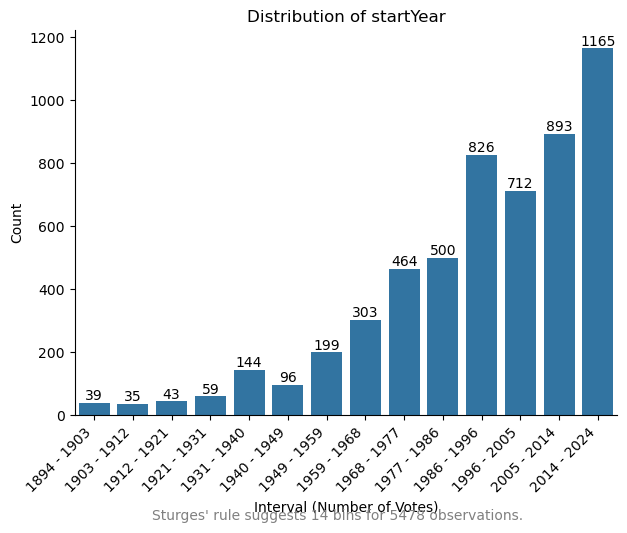

,Interval,film_count
0,1894 - 1903,39
1,1903 - 1912,35
2,1912 - 1921,43
3,1921 - 1931,59
4,1931 - 1940,144
5,1940 - 1949,96
6,1949 - 1959,199
7,1959 - 1968,303
8,1968 - 1977,464
9,1977 - 1986,500


In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def generate_distribution_chart(data, column, title=None, xlabel=None, ylabel=None, use_sturges=False):
    """
    Generates a bar plot showing the distribution of a specified column and returns the distribution data.

    Parameters:
        data (pd.DataFrame): The dataset containing the columns.
        column (str): The column for which the distribution is calculated.
        title (str, optional): Title of the chart. Default is None.
        xlabel (str, optional): Label for the x-axis. Default is None.
        ylabel (str, optional): Label for the y-axis. Default is None.
        use_sturges (bool, optional): If True, uses Sturges' rule to determine the number of bins for the distribution.

    Returns:
        pd.DataFrame: A DataFrame containing the intervals and the count of rows in each interval.
    """
    if column in data.columns:
        # Calculate distribution
        if use_sturges:
            num_bins = int(np.ceil(1 + np.log2(len(data[column].dropna()))))  # Sturges' rule
            min_value = data[column].min()
            max_value = data[column].max()
            bins = np.linspace(min_value, max_value, num_bins + 1)
            bin_labels = [f"{int(bins[i])} - {int(bins[i + 1])}" for i in range(len(bins) - 1)]
            data['binned'] = pd.cut(data[column], bins=bins, include_lowest=True, labels=bin_labels)
            distribution = data['binned'].value_counts(sort=False).reset_index()
            distribution.columns = ['Interval', 'film_count']
            description = f"Sturges' rule suggests {num_bins} bins for {len(data[column].dropna())} observations."
        else:
            distribution = data[column].value_counts().reset_index()
            distribution.columns = [column, 'film_count']
            distribution = distribution.sort_values(by=column)
            description = None

        # Plotting
        plt.figure(figsize=(7, 5))
        ax = sns.barplot(x='Interval' if use_sturges else column, y='film_count', data=distribution)
        plt.title(title if title else f'Distribution of {column}')
        plt.xlabel(xlabel if xlabel else (column if not use_sturges else 'Interval (Number of Votes)'))
        plt.ylabel(ylabel if ylabel else 'Count')
        
        # Rotate x-axis labels diagonally if using Sturges' rule
        if use_sturges:
            plt.xticks(rotation=45, ha='right')
        
        # Add value labels on each bar
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, color='black')
        
        # Remove top and right borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # Add description for Sturges' rule if applicable
        if description:
            plt.figtext(0.5, -0.1, description, wrap=True, horizontalalignment='center', fontsize=10, color='gray')

        plt.show()

        # Drop temporary 'binned' column if it was created
        if 'binned' in data.columns:
            data.drop(columns=['binned'], inplace=True)

        return distribution
    else:
        raise ValueError(f"Column {column} not found in the dataset.")

generate_distribution_chart(data_train, 'numVotes', use_sturges = True)
generate_distribution_chart(data_test, 'numVotes', use_sturges = True)

generate_distribution_chart(data_train, 'startYear', use_sturges = True)

/tmp/ipykernel_37498/630372876.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




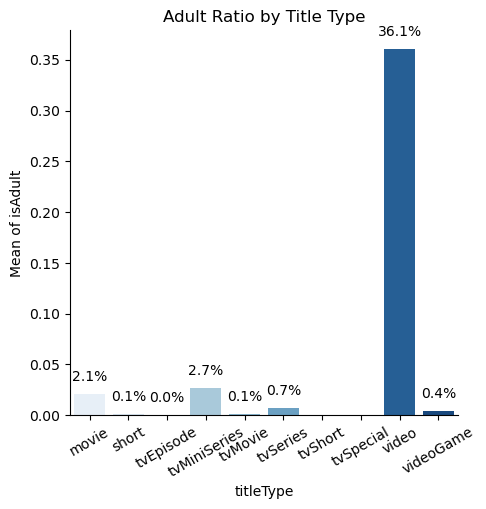

/tmp/ipykernel_37498/630372876.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




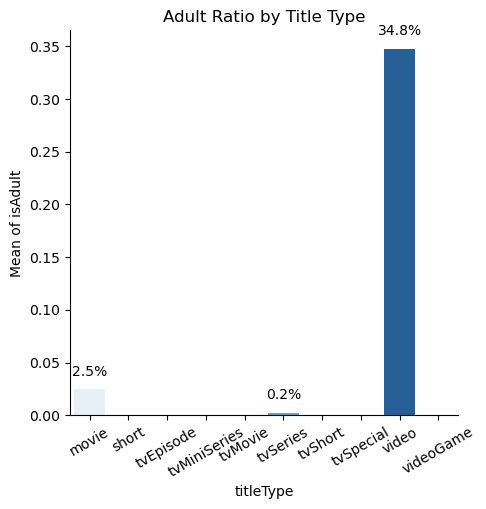

In [117]:

def generate_ratio_chart(data, group_col, value_col, title=None, xlabel=None, ylabel=None, palette="Blues"):
    if group_col in data.columns and value_col in data.columns:
        ratio = data.groupby(group_col)[value_col].mean()
        plt.figure(figsize=(5, 5))
        ax = sns.barplot(x=ratio.index, y=ratio.values, palette=sns.color_palette(palette, len(ratio)))
        
        # Add percentage labels to each bar (exclude 0.0%)
        for i, value in enumerate(ratio.values):
            if value > 0:
                ax.text(i, value + 0.01, f'{value:.1%}', ha='center', va='bottom', fontsize=10)
        
        # Remove top and right borders
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.xticks(rotation=30)
        plt.title(title if title else f'Mean of {value_col} by {group_col}')
        plt.xlabel(xlabel if xlabel else group_col)
        plt.ylabel(ylabel if ylabel else f'Mean of {value_col}')
        plt.show()
    else:
        raise ValueError(f"Columns {group_col} and/or {value_col} not found in the dataset.")


generate_ratio_chart(data_test, 'titleType', 'isAdult', 'Adult Ratio by Title Type')
generate_ratio_chart(data_train, 'titleType', 'isAdult', 'Adult Ratio by Title Type')

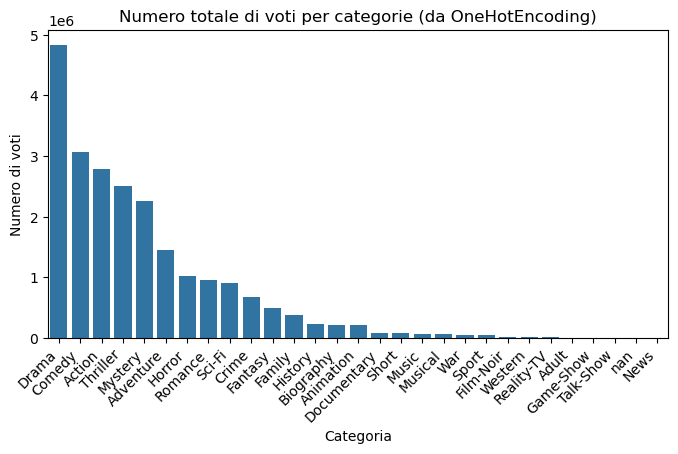

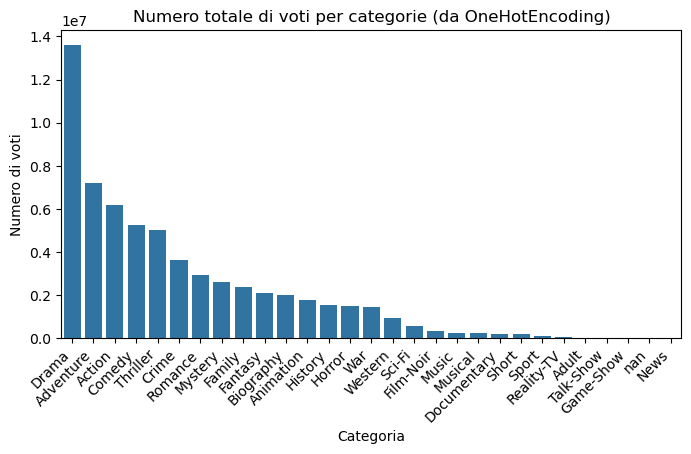

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_votes_by_genre(data, genre_column, vote_column):
    """Generate a bar plot for total votes by genre."""
    data_genres = data.assign(genres=data[genre_column].str.split(',')).explode(genre_column)
    votes_by_genre = data_genres.groupby(genre_column)[vote_column].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=votes_by_genre.index, y=votes_by_genre.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Numero totale di voti per genere')
    plt.xlabel('Genere')
    plt.ylabel('Numero di voti')
    plt.show()

def plot_from_onehot_file(data, file_path, vote_column):
    """Generate a bar plot using columns specified in a .txt file with one-hot encoding columns."""
    # Read the columns of interest from the file
    with open(file_path, 'r') as f:
        onehot_columns = [line.strip() for line in f.readlines()]

    # Filter out missing columns
    available_columns = [col for col in onehot_columns if col in data.columns]
    missing_columns = [col for col in onehot_columns if col not in data.columns]

    if missing_columns:
        print(f"Warning: The following columns are missing and will be ignored: {missing_columns}")

    # Aggregate votes for each available column
    votes_by_column = data[available_columns].multiply(data[vote_column], axis=0).sum().sort_values(ascending=False)

    # Create the bar plot
    plt.figure(figsize=(8, 4))
    sns.barplot(x=votes_by_column.index, y=votes_by_column.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Numero totale di voti per categorie (da OneHotEncoding)')
    plt.xlabel('Categoria')
    plt.ylabel('Numero di voti')
    plt.show()


plot_from_onehot_file(data_train, 'encoding_lists/genres.txt', 'numVotes')
plot_from_onehot_file(data_test, 'encoding_lists/genres.txt', 'numVotes')

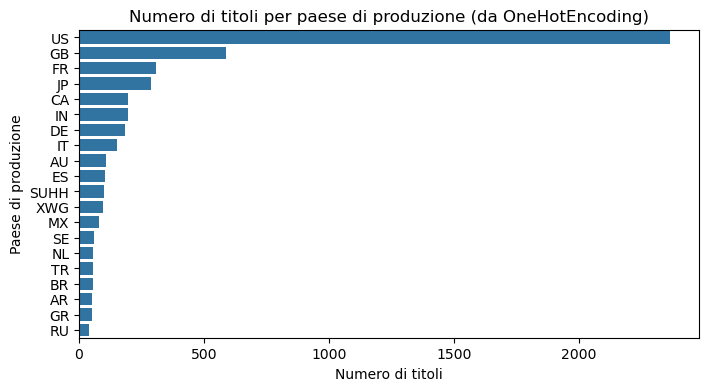

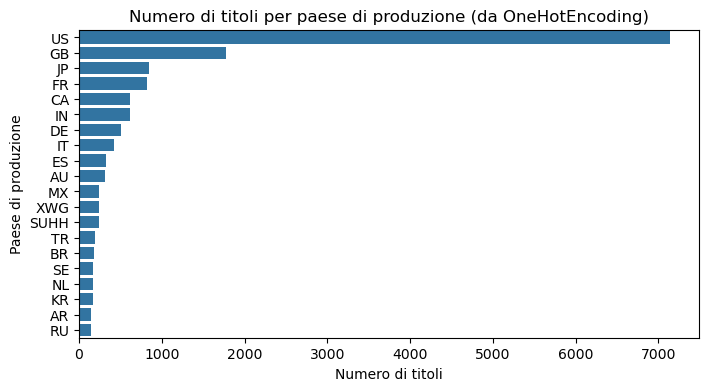

In [119]:

def plot_titles_by_country(data, country_column):
    """Generate a bar plot for the number of titles by country."""
    data_countries = data.assign(countryOfOrigin=data[country_column].str.strip("[]").str.replace("'", "").str.split(',')).explode(country_column)
    data_countries[country_column] = data_countries[country_column].str.strip()

    titles_by_country = data_countries[country_column].value_counts().head(20)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=titles_by_country.values, y=titles_by_country.index)
    plt.title('Numero di titoli per paese di produzione')
    plt.xlabel('Numero di titoli')
    plt.ylabel('Paese di produzione')
    plt.show()


def plot_titles_from_onehot_file(data, file_path):
    """Generate a bar plot using columns specified in a .txt file with one-hot encoding columns for countries."""
    # Read the columns of interest from the file
    with open(file_path, 'r') as f:
        onehot_columns = [line.strip() for line in f.readlines()]

    # Filter out missing columns
    available_columns = [col for col in onehot_columns if col in data.columns]
    missing_columns = [col for col in onehot_columns if col not in data.columns]

    if missing_columns:
        print(f"Warning: The following columns are missing and will be ignored: {missing_columns}")

    # Count titles for each available column
    titles_by_column = data[available_columns].sum().sort_values(ascending=False).head(20)

    # Create the bar plot
    plt.figure(figsize=(8, 4))
    sns.barplot(x=titles_by_column.values, y=titles_by_column.index)
    plt.title('Numero di titoli per paese di produzione (da OneHotEncoding)')
    plt.xlabel('Numero di titoli')
    plt.ylabel('Paese di produzione')
    plt.show()


plot_titles_from_onehot_file(data_train, 'encoding_lists/countryOfOrigin.txt')
plot_titles_from_onehot_file(data_test, 'encoding_lists/countryOfOrigin.txt')

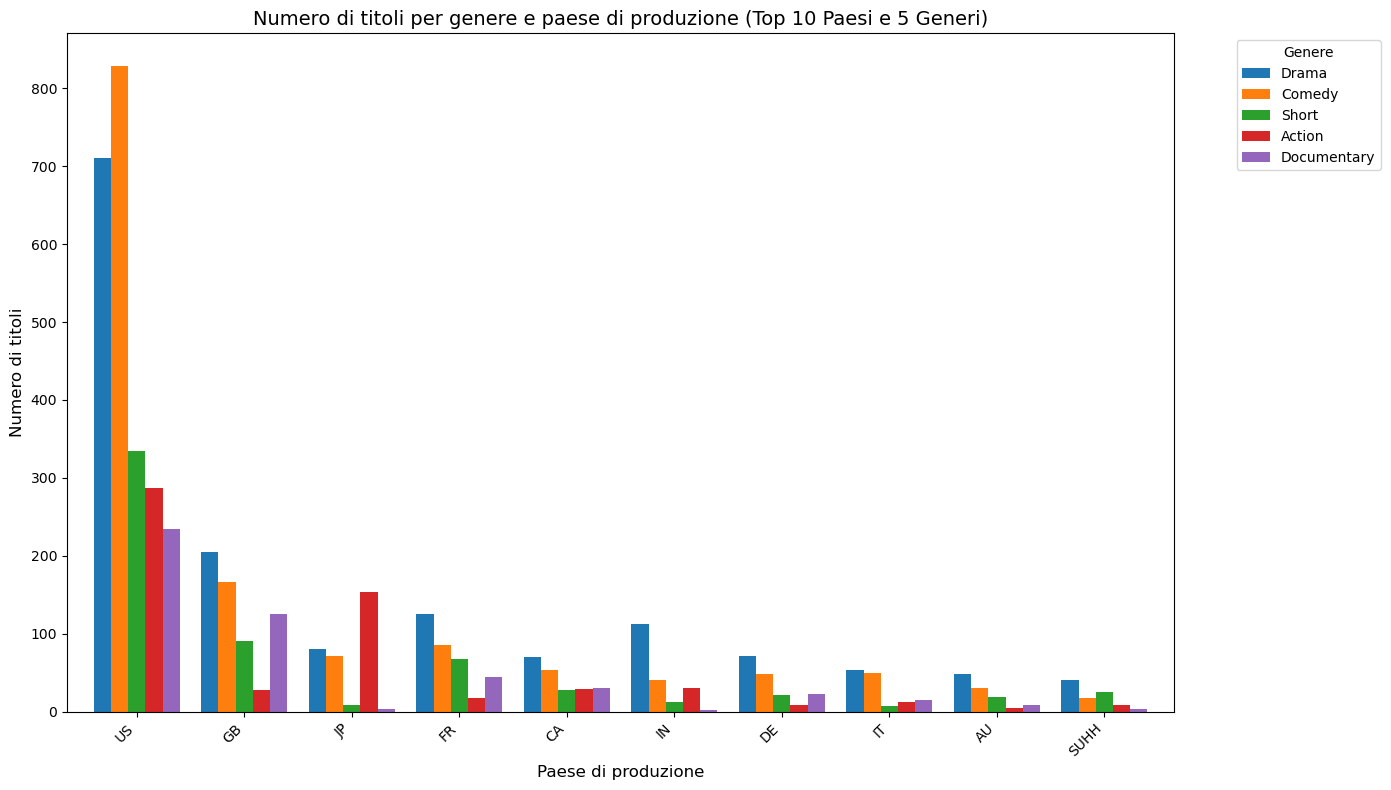

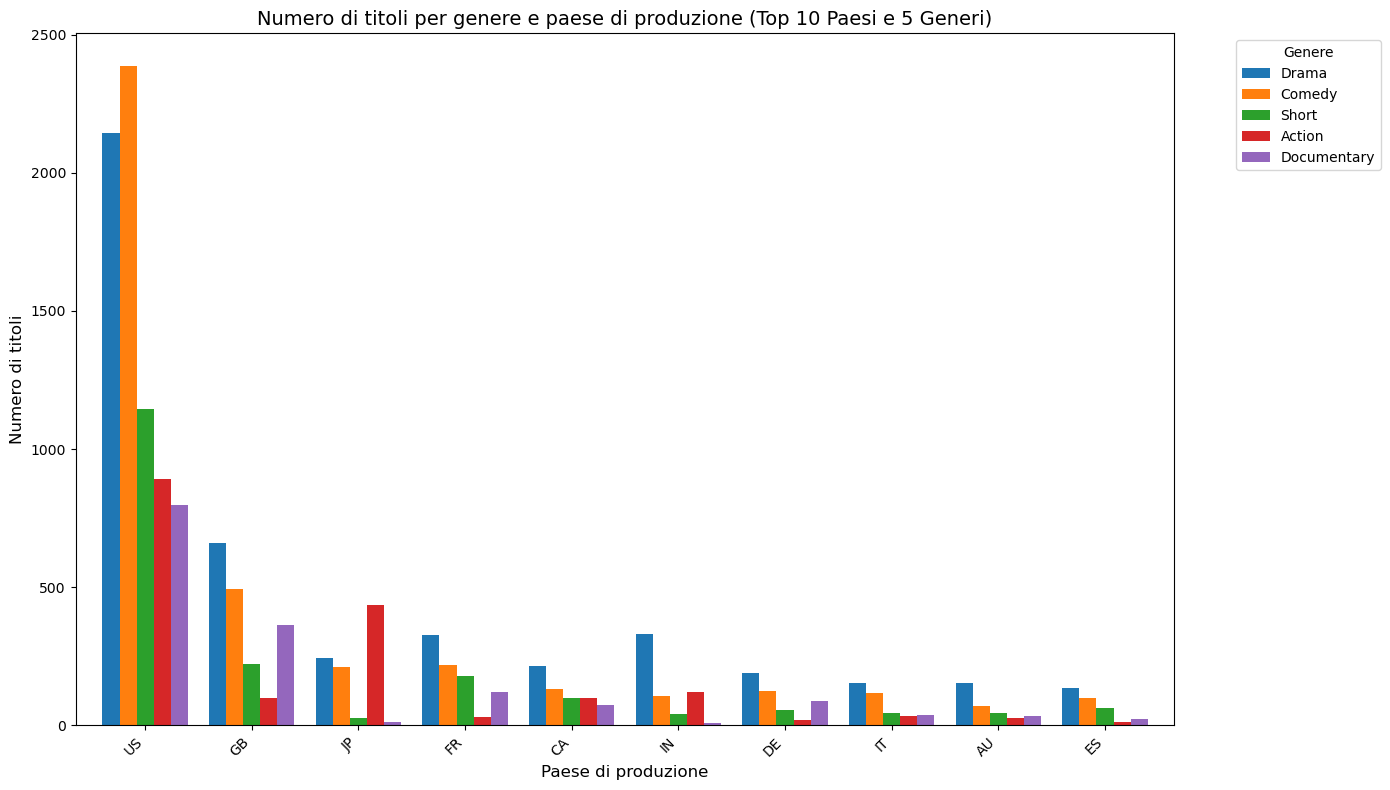

In [120]:

def plot_titles_by_genre_and_country(data, genre_column, country_column, top_countries=10, top_genres=5):
    """Generate a grouped bar plot for the number of titles by genre and country."""
    data_cleaned = data.assign(
        genres=data[genre_column].str.strip("[]").str.replace("'", "").str.split(','),
        countryOfOrigin=data[country_column].str.strip("[]").str.replace("'", "").str.split(',')
    )
    data_genres_countries = data_cleaned.explode('genres').explode('countryOfOrigin')
    data_genres_countries['genres'] = data_genres_countries['genres'].str.strip()
    data_genres_countries['countryOfOrigin'] = data_genres_countries['countryOfOrigin'].str.strip()
    data_genres_countries = data_genres_countries.dropna(subset=['genres', 'countryOfOrigin'])

    genre_country_counts = data_genres_countries.groupby(['countryOfOrigin', 'genres']).size().reset_index(name='count')

    pivot = genre_country_counts.pivot(index='countryOfOrigin', columns='genres', values='count').fillna(0)

    top_countries_list = genre_country_counts['countryOfOrigin'].value_counts().head(top_countries).index
    top_genres_list = genre_country_counts['genres'].value_counts().head(top_genres).index

    filtered_data = genre_country_counts[
        (genre_country_counts['countryOfOrigin'].isin(top_countries_list)) &
        (genre_country_counts['genres'].isin(top_genres_list))
    ]

    pivot_grouped = filtered_data.pivot(index='countryOfOrigin', columns='genres', values='count').fillna(0)

    pivot_grouped.plot(kind='bar', figsize=(14, 8), width=0.8)
    plt.title('Numero di titoli per genere e paese di produzione (Top 10 Paesi e 5 Generi)', fontsize=14)
    plt.xlabel('Paese di produzione', fontsize=12)
    plt.ylabel('Numero di titoli', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(title='Genere', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_titles_by_genre_and_country(data, genre_file, country_file, top_countries=10, top_genres=5):
    """Generate a grouped bar plot for the number of titles by genre and country using double one-hot encoding."""
    # Read the one-hot encoding columns from the files
    with open(genre_file, 'r') as f:
        genre_columns = [line.strip() for line in f.readlines()]

    with open(country_file, 'r') as f:
        country_columns = [line.strip() for line in f.readlines()]

    # Filter out missing columns
    available_genre_columns = [col for col in genre_columns if col in data.columns]
    missing_genre_columns = [col for col in genre_columns if col not in data.columns]

    available_country_columns = [col for col in country_columns if col in data.columns]
    missing_country_columns = [col for col in country_columns if col not in data.columns]

    if missing_genre_columns:
        print(f"Warning: The following genre columns are missing and will be ignored: {missing_genre_columns}")

    if missing_country_columns:
        print(f"Warning: The following country columns are missing and will be ignored: {missing_country_columns}")

    # Create a DataFrame for the counts of genre-country combinations
    genre_country_counts = pd.DataFrame()

    for country in available_country_columns:
        for genre in available_genre_columns:
            genre_country_counts.loc[country, genre] = (data[country] * data[genre]).sum()

    # Filter for top countries and genres
    top_countries_list = genre_country_counts.sum(axis=1).nlargest(top_countries).index
    top_genres_list = genre_country_counts.sum(axis=0).nlargest(top_genres).index

    filtered_counts = genre_country_counts.loc[top_countries_list, top_genres_list]

    # Plot the grouped bar plot
    filtered_counts.plot(kind='bar', figsize=(14, 8), width=0.8)
    plt.title('Numero di titoli per genere e paese di produzione (Top 10 Paesi e 5 Generi)', fontsize=14)
    plt.xlabel('Paese di produzione', fontsize=12)
    plt.ylabel('Numero di titoli', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(title='Genere', fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_titles_by_genre_and_country(data_train, 'encoding_lists/genres.txt', 'encoding_lists/countryOfOrigin.txt')
plot_titles_by_genre_and_country(data_test, 'encoding_lists/genres.txt', 'encoding_lists/countryOfOrigin.txt')

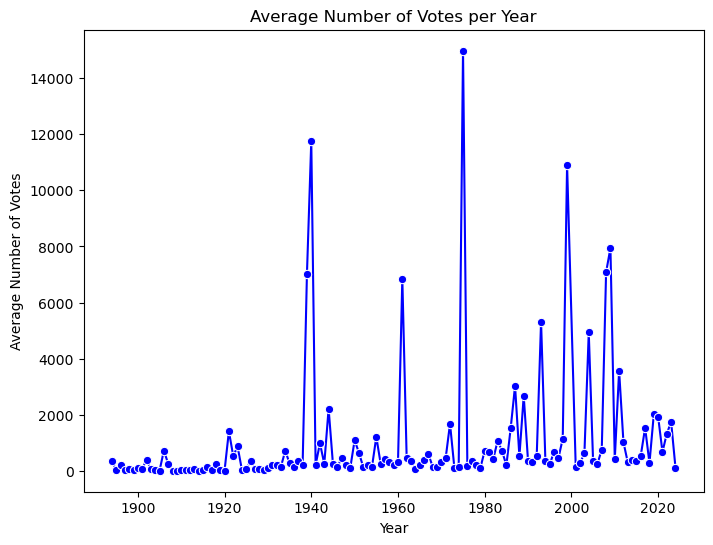

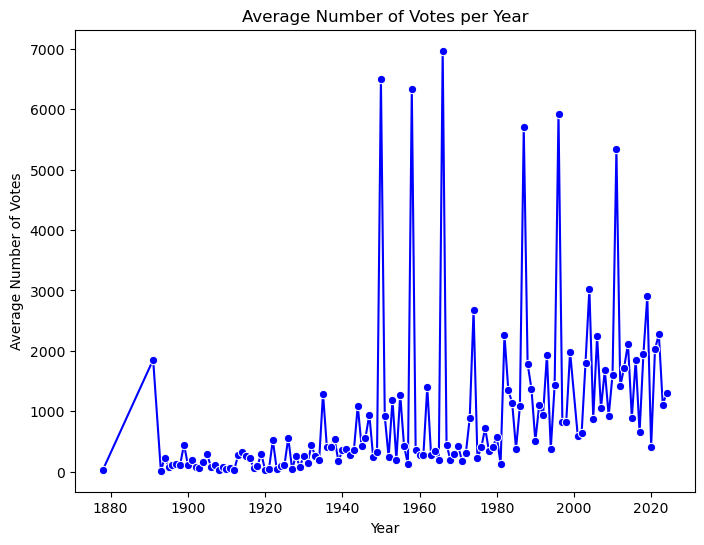

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_line_average(data, group_by_column, value_column, title, xlabel, ylabel, marker='o', color='blue'):
    """
    Crea un lineplot che mostra la media dei valori di una colonna raggruppati per un'altra colonna.
    """
    avg_values = data.groupby(group_by_column)[value_column].mean().reset_index()
    plt.figure(figsize=(8, 6))
    sns.lineplot(x=group_by_column, y=value_column, data=avg_values, marker=marker, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

plot_line_average(data_train, 'startYear', 'numVotes', 'Average Number of Votes per Year', 'Year', 'Average Number of Votes')
plot_line_average(data_test, 'startYear', 'numVotes', 'Average Number of Votes per Year', 'Year', 'Average Number of Votes')

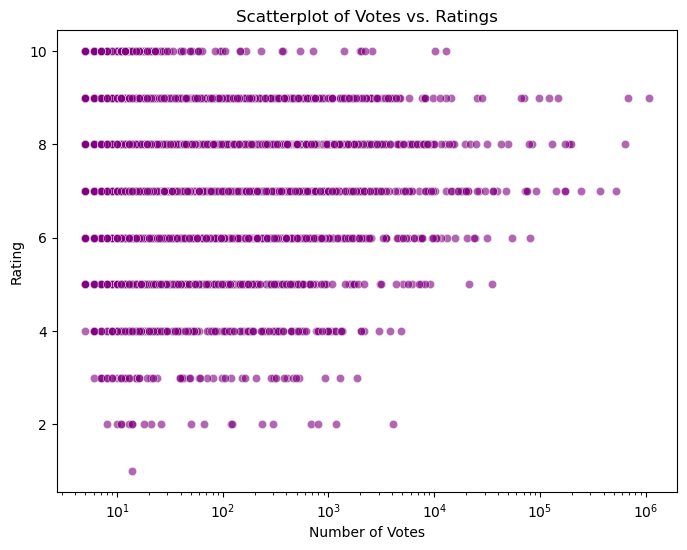

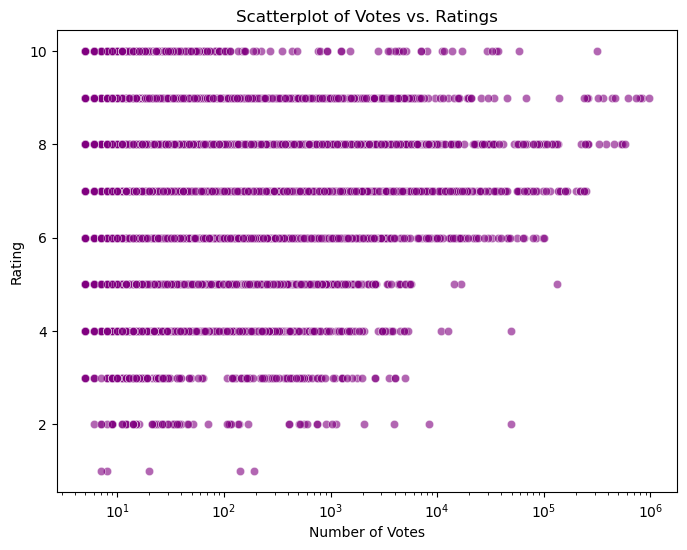

In [122]:

def plot_scatter(data, x_column, y_column, title, xlabel, ylabel, alpha=0.6, color='purple', log_scale_x=False):
    """
    Crea uno scatterplot tra due colonne specificate.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=x_column, y=y_column, data=data, alpha=alpha, color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if log_scale_x:
        plt.xscale('log')  # Scala logaritmica per l'asse x se richiesto
    plt.show()

plot_scatter(data_train, 'numVotes', 'rating', 'Scatterplot of Votes vs. Ratings', 'Number of Votes', 'Rating', log_scale_x=True)
plot_scatter(data_test, 'numVotes', 'rating', 'Scatterplot of Votes vs. Ratings', 'Number of Votes', 'Rating', log_scale_x=True)


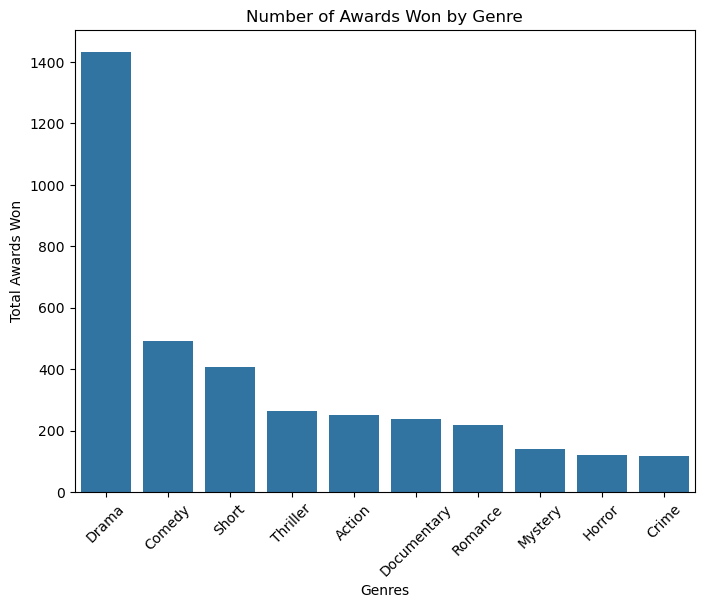

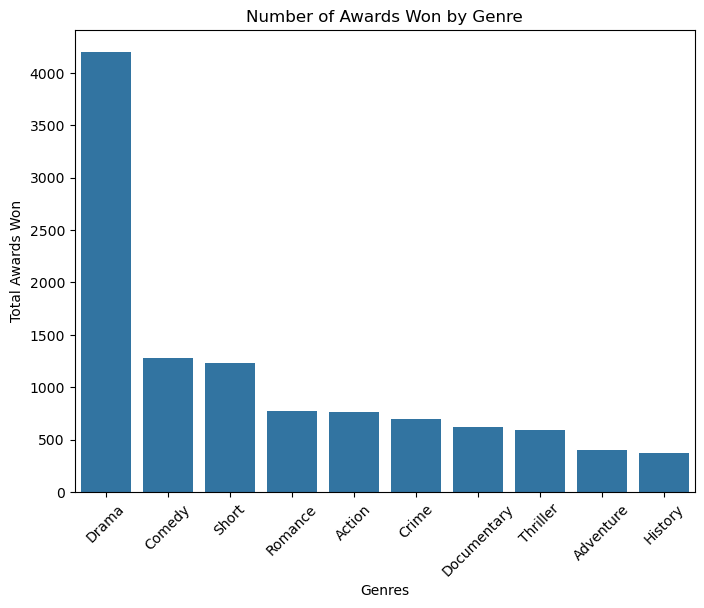

In [123]:

def plot_bar_grouped_sum(data, group_by_column, value_column, title, xlabel, ylabel, top_n=10):
    """
    Crea un barplot che mostra la somma dei valori di una colonna raggruppati per un'altra colonna.
    """
    grouped_data = data.assign(group=data[group_by_column].str.split(',')).explode('group')
    grouped_sum = grouped_data.groupby('group')[value_column].sum().sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=grouped_sum.index, y=grouped_sum.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.show()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bar_grouped_sum_onehot(data, onehot_file, value_column, title, xlabel, ylabel, top_n=10):
    """
    Crea un barplot che mostra la somma dei valori di una colonna basata su colonne one-hot encoding.
    
    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati.
        onehot_file (str): Percorso del file .txt con i nomi delle colonne one-hot encoding.
        value_column (str): La colonna dei valori da sommare.
        title (str): Titolo del grafico.
        xlabel (str): Etichetta dell'asse x.
        ylabel (str): Etichetta dell'asse y.
        top_n (int): Numero massimo di categorie da mostrare.
    """
    # Leggere le colonne one-hot dal file
    with open(onehot_file, 'r') as f:
        onehot_columns = [line.strip() for line in f.readlines()]

    # Filtrare le colonne disponibili nel DataFrame
    available_columns = [col for col in onehot_columns if col in data.columns]
    missing_columns = [col for col in onehot_columns if col not in data.columns]

    if missing_columns:
        print(f"Warning: The following columns are missing and will be ignored: {missing_columns}")

    # Calcolare la somma per ciascuna colonna disponibile
    grouped_sum = data[available_columns].multiply(data[value_column], axis=0).sum().sort_values(ascending=False).head(top_n)

    # Creare il grafico
    plt.figure(figsize=(8, 6))
    sns.barplot(x=grouped_sum.index, y=grouped_sum.values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.show()

# Esempio di chiamata
plot_bar_grouped_sum_onehot(data_train, 'encoding_lists/genres.txt', 'awardWins', 'Number of Awards Won by Genre', 'Genres', 'Total Awards Won')
plot_bar_grouped_sum_onehot(data_test, 'encoding_lists/genres.txt', 'awardWins', 'Number of Awards Won by Genre', 'Genres', 'Total Awards Won')


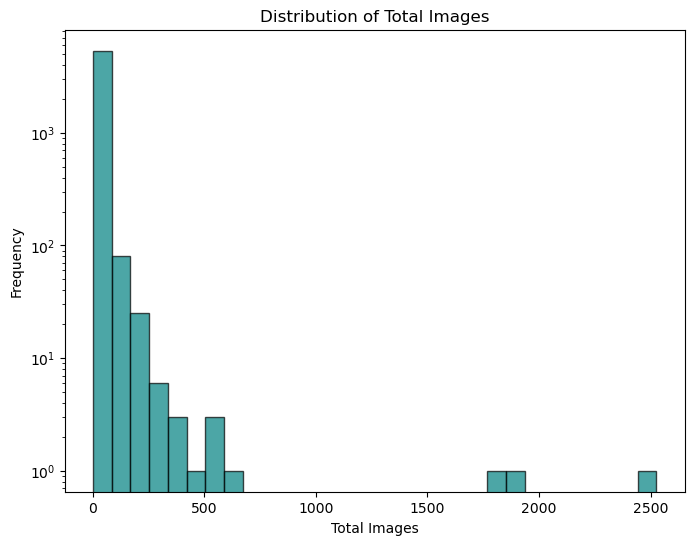

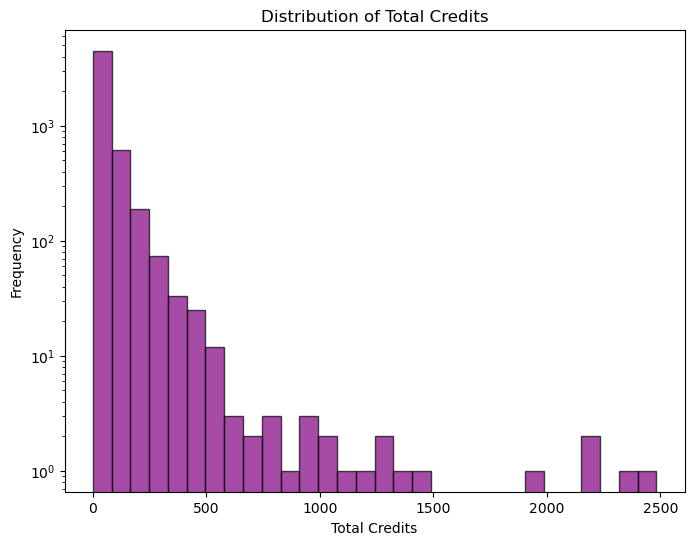

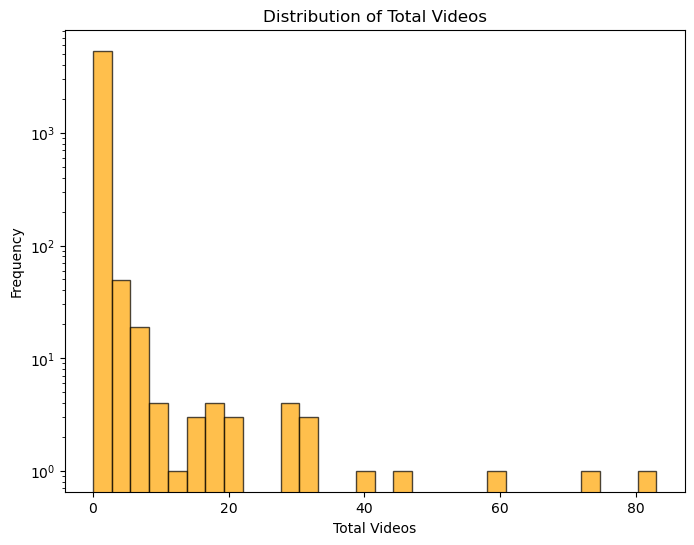

In [124]:
# Histogram: Distribution of Total Images, Total Credits, Total Videos
plt.figure(figsize=(8, 6))
plt.hist(data_train['totalImages'], bins=30, color='teal', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Images')
plt.xlabel('Total Images')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(data_train['totalCredits'], bins=30, color='purple', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Credits')
plt.xlabel('Total Credits')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(data_train['totalVideos'], bins=30, color='orange', alpha=0.7, edgecolor='black')
plt.title('Distribution of Total Videos')
plt.xlabel('Total Videos')
plt.ylabel('Frequency')
plt.yscale('log')  # Log scale to better visualize the skewed distribution
plt.show()


/tmp/ipykernel_37498/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_37498/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_37498/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_37498/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

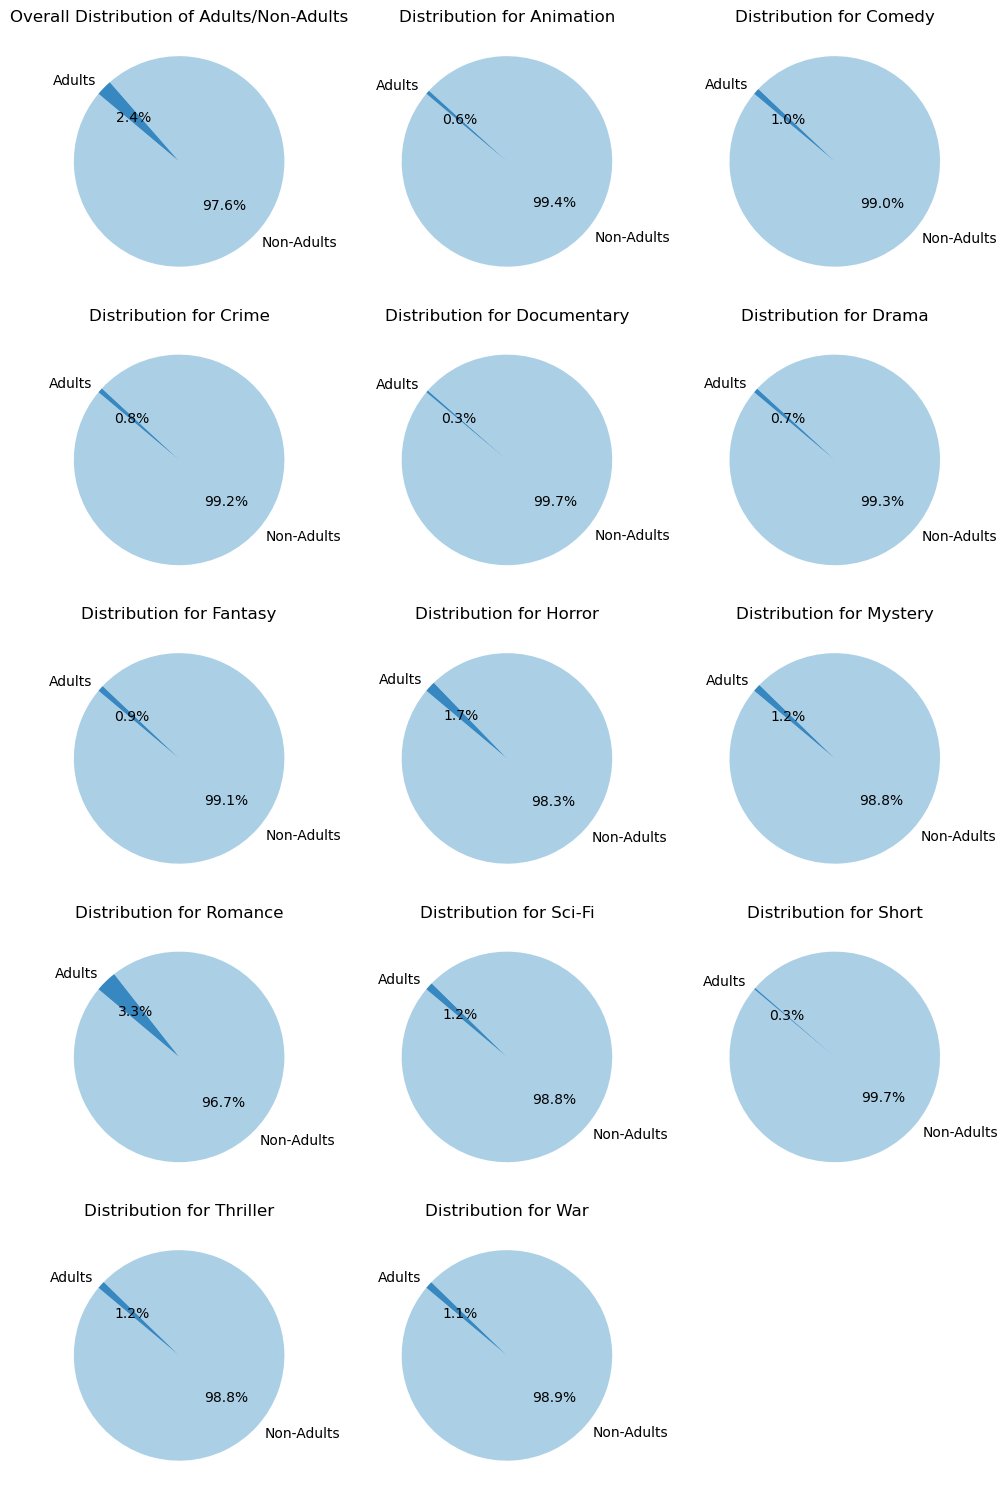

Genres without adult products: ['Action', 'Adult', 'Adventure', 'Biography', 'Family', 'Film-Noir', 'Game-Show', 'History', 'Music', 'Musical', 'News', 'Reality-TV', 'Sport', 'Talk-Show', 'Western', 'nan']


/tmp/ipykernel_37498/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_37498/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_37498/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_37498/671212858.py:52: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

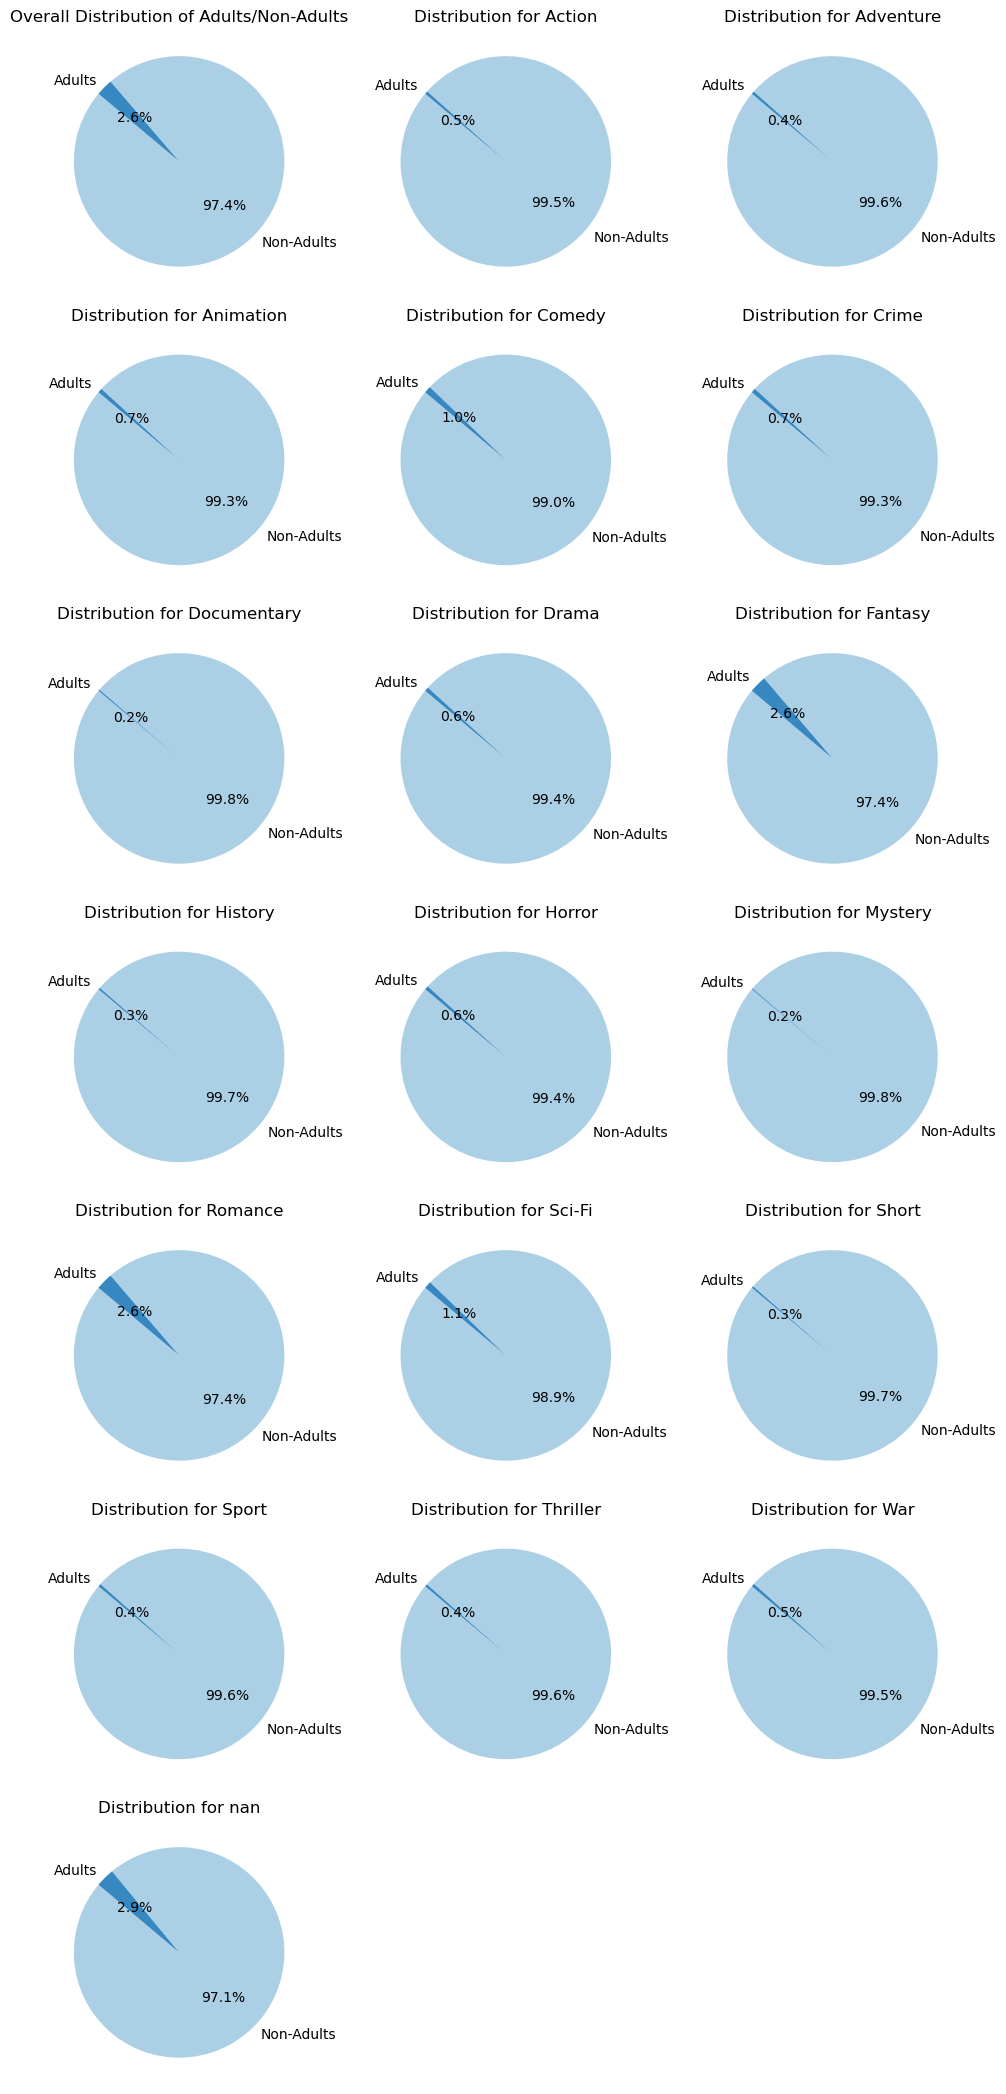

Genres without adult products: ['Adult', 'Biography', 'Family', 'Film-Noir', 'Game-Show', 'Music', 'Musical', 'News', 'Reality-TV', 'Talk-Show', 'Western']


In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_isAdult_distribution(data, onehot_file):
    """
    Crea un'unica immagine con grafici a torta per la distribuzione di isAdult complessiva e per ogni genere.
    Utilizza il colorscheme "Blues".

    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati.
        onehot_file (str): Percorso del file .txt con i nomi delle colonne one-hot encoding.
    """
    # Leggere le colonne one-hot dal file
    with open(onehot_file, 'r') as f:
        onehot_columns = [line.strip() for line in f.readlines()]

    # Filtrare le colonne disponibili nel DataFrame
    available_columns = [col for col in onehot_columns if col in data.columns]
    missing_columns = [col for col in onehot_columns if col not in data.columns]

    if missing_columns:
        print(f"Warning: The following columns are missing and will be ignored: {missing_columns}")

    # Lista dei generi senza prodotti per adulti
    no_adult_genres = []

    # Determinare il numero totale di grafici
    num_plots = len(available_columns) + 1  # Include il grafico generale
    cols = 3  # Numero di colonne nel layout
    rows = (num_plots // cols) + (num_plots % cols > 0)  # Calcolo delle righe necessarie

    # Creare il layout della figura
    fig, axes = plt.subplots(rows, cols, figsize=(10, rows * 3))
    axes = axes.flatten()

    # Grafico generale per isAdult
    general_ax = axes[0]
    data['isAdult'].value_counts().plot.pie(
        autopct='%1.1f%%', labels=['Non-Adults', 'Adults'], colors=sns.color_palette("Blues", 2), startangle=140, ax=general_ax
    )
    general_ax.set_title('Overall Distribution of Adults/Non-Adults')
    general_ax.set_ylabel('')

    plot_index = 1  # Indice per i grafici validi

    # Grafici per ogni genere
    for genre in available_columns:
        genre_data = data[data[genre] == 1]  # Filtra per il genere corrente
        if not genre_data.empty:
            counts = genre_data['isAdult'].value_counts(normalize=True)
            if counts.get(1, 0) == 0:  # Controlla se non ci sono prodotti per adulti
                no_adult_genres.append(genre)
                continue

            genre_ax = axes[plot_index]
            genre_data['isAdult'].value_counts().plot.pie(
                autopct='%1.1f%%', labels=['Non-Adults', 'Adults'], colors=sns.color_palette("Blues", 2), startangle=140, ax=genre_ax
            )
            genre_ax.set_title(f'Distribution for {genre}')
            genre_ax.set_ylabel('')
            plot_index += 1

    # Rimuovere assi vuoti
    for j in range(plot_index, len(axes)):
        fig.delaxes(axes[j])

    # Layout finale
    plt.tight_layout()
    plt.show()

    # Stampa dei generi senza prodotti per adulti
    if no_adult_genres:
        print(f"Genres without adult products: {no_adult_genres}")



# Esempio di chiamata
plot_isAdult_distribution(data_train, 'encoding_lists/genres.txt')
plot_isAdult_distribution(data_test, 'encoding_lists/genres.txt')

# analisi grafico 2
Analisi del grafico
Distribuzione uniforme per rating:

I valori di rating sembrano distribuiti in modo simile per la maggior parte dei generi. Non ci sono generi con valori estremi (molto alti o bassi).
Differenze marcate in numVotes:

Il numero di voti (numVotes) è un discriminante significativo. Alcuni generi, come "Drama" e "Action", tendono ad avere un numero di voti molto alto, mentre generi come "Short", "Family", e "Crime" ne hanno relativamente pochi.
awardWins più bassi per alcuni generi:

Generi come "Drama" e "Documentary" mostrano un maggiore numero di premi vinti, rispetto a generi come "Family" o "Short", che generalmente ottengono meno riconoscimenti.
Picchi per alcuni generi specifici:

"Drama" e "Documentary" si distinguono come generi con un buon bilanciamento tra i tre parametri (rating, numVotes, awardWins).
"Short" e "Family" tendono a essere poco rappresentati in termini di numVotes e awardWins.

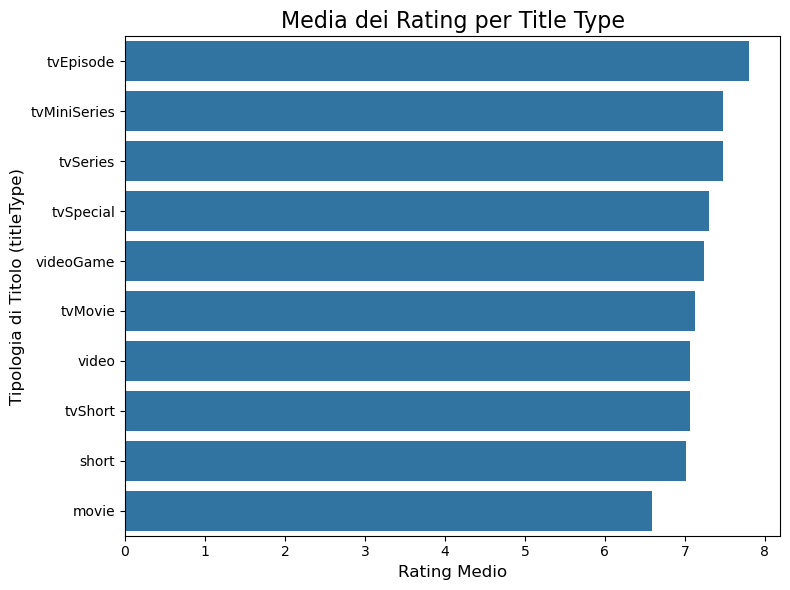

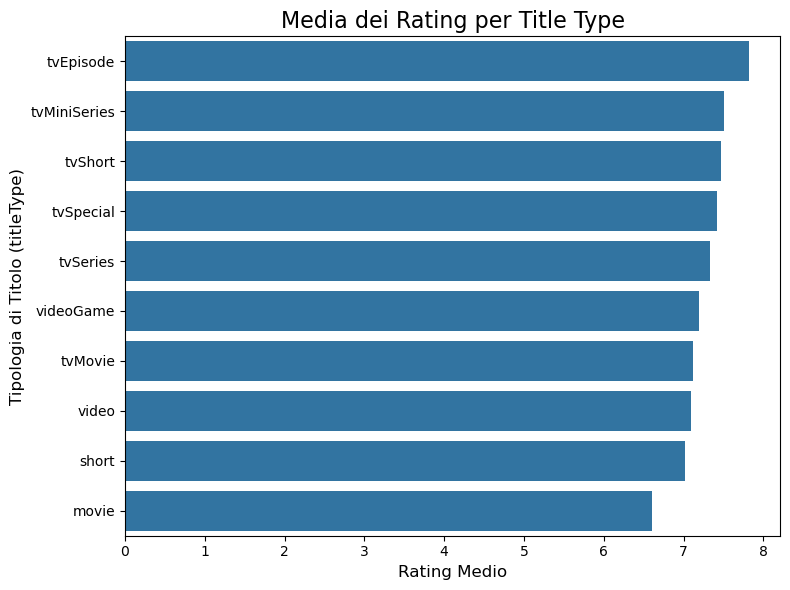

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_average_rating_by_title_type(data):
    """
    Crea un barplot che mostra la media dei rating per ogni tipo di titolo (titleType).

    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati con le colonne 'titleType' e 'rating'.
    """
    # Calcoliamo la media dei rating per ogni tipo di titolo
    rating_by_type = data.groupby('titleType')['rating'].mean().sort_values(ascending=False).reset_index()

    # Creazione del barplot
    plt.figure(figsize=(8, 6))
    sns.barplot(x='rating', y='titleType', data=rating_by_type)

    plt.title('Media dei Rating per Title Type', fontsize=16)
    plt.xlabel('Rating Medio', fontsize=12)
    plt.ylabel('Tipologia di Titolo (titleType)', fontsize=12)
    plt.tight_layout()
    plt.show()

plot_average_rating_by_title_type(data_train)
plot_average_rating_by_title_type(data_test)


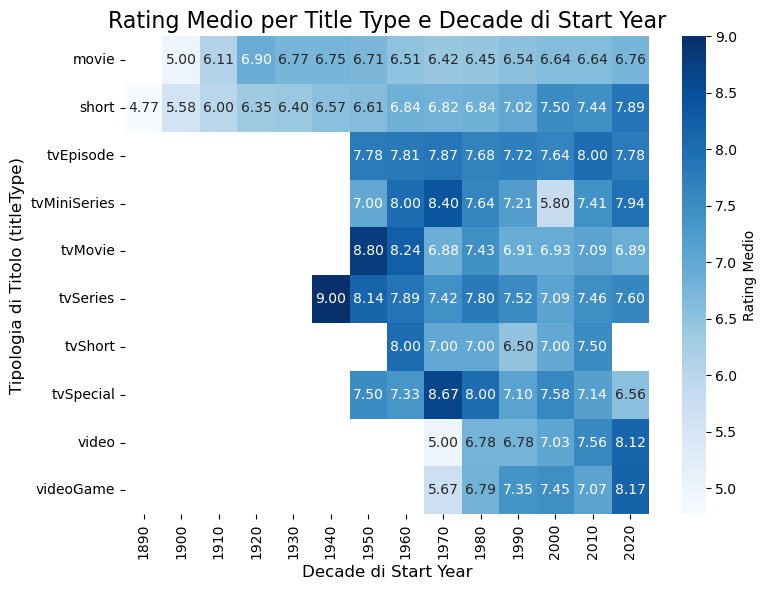

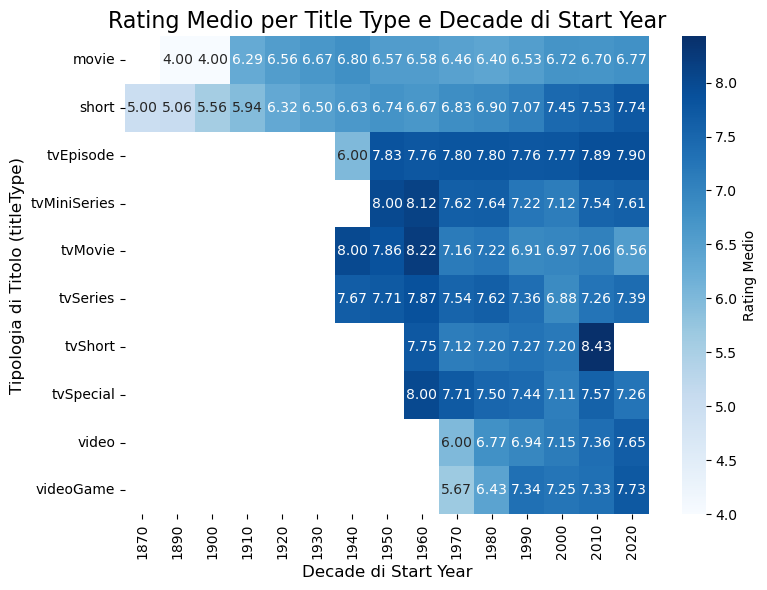

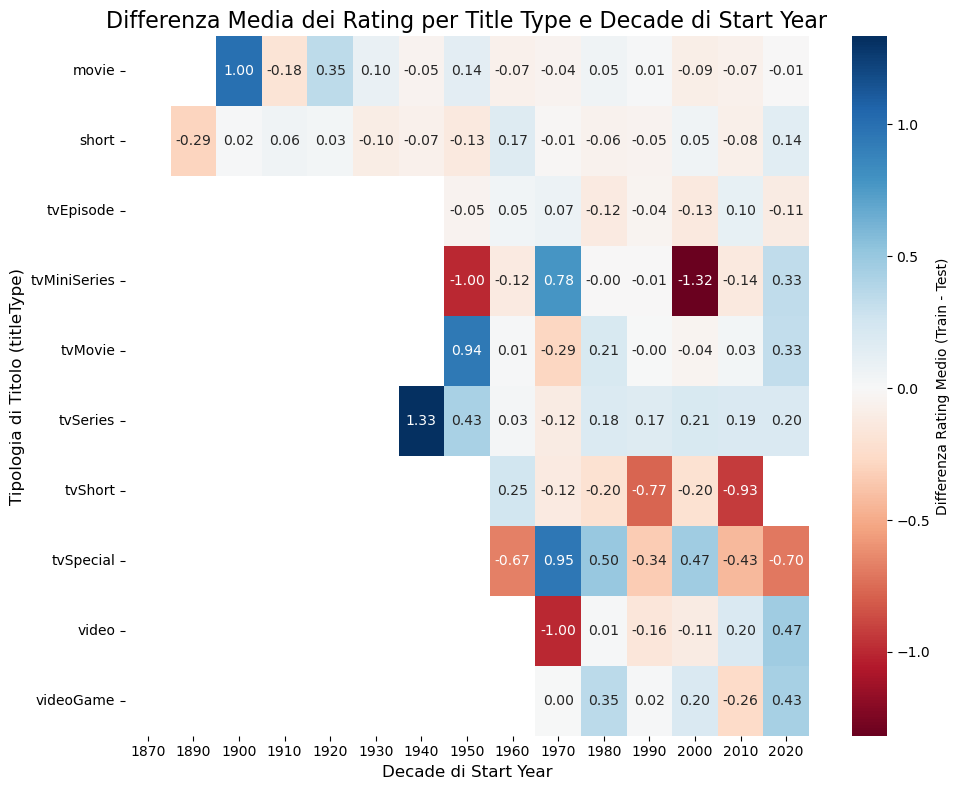

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap_rating_by_title_type_and_decade(data):
    """
    Crea una heatmap che mostra il rating medio per combinazioni di titleType e decade di startYear.

    Args:
        data (pd.DataFrame): Il DataFrame contenente i dati con le colonne 'titleType', 'startYear', e 'rating'.
    """
    # Creiamo una colonna per categorizzare 'startYear' in intervalli (decadi)
    data['startYearDecade'] = (data['startYear'] // 10) * 10

    # Calcoliamo la media dei rating per combinazioni di titleType e decade
    heatmap_data = data.groupby(['titleType', 'startYearDecade'])['rating'].mean().unstack()

    # Creazione della heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        cbar_kws={'label': 'Rating Medio'}
    )

    plt.title('Rating Medio per Title Type e Decade di Start Year', fontsize=16)
    plt.xlabel('Decade di Start Year', fontsize=12)
    plt.ylabel('Tipologia di Titolo (titleType)', fontsize=12)
    plt.tight_layout()
    plt.show()

def plot_comparison_heatmap(data_train, data_test):
    """
    Crea una heatmap che confronta i rating medi tra data_train e data_test per titleType e startYear decade.

    Args:
        data_train (pd.DataFrame): Il dataset di training.
        data_test (pd.DataFrame): Il dataset di test.
    """
    # Creiamo una colonna per categorizzare 'startYear' in intervalli (decadi)
    data_train['startYearDecade'] = (data_train['startYear'] // 10) * 10
    data_test['startYearDecade'] = (data_test['startYear'] // 10) * 10

    # Calcoliamo la media dei rating per combinazioni di titleType e decade
    train_heatmap_data = data_train.groupby(['titleType', 'startYearDecade'])['rating'].mean().unstack()
    test_heatmap_data = data_test.groupby(['titleType', 'startYearDecade'])['rating'].mean().unstack()

    # Sottraiamo i dati di test da quelli di training
    comparison_data = train_heatmap_data - test_heatmap_data

    # Creazione della heatmap con scala colori personalizzata
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        comparison_data,
        annot=True,
        fmt=".2f",
        cmap="RdBu",
        center=0,
        cbar_kws={'label': 'Differenza Rating Medio (Train - Test)'}
    )

    plt.title('Differenza Media dei Rating per Title Type e Decade di Start Year', fontsize=16)
    plt.xlabel('Decade di Start Year', fontsize=12)
    plt.ylabel('Tipologia di Titolo (titleType)', fontsize=12)
    plt.tight_layout()
    plt.show()

# Esempi di chiamata
plot_heatmap_rating_by_title_type_and_decade(data_train)
plot_heatmap_rating_by_title_type_and_decade(data_test)
plot_comparison_heatmap(data_train, data_test)


### Outliers

In [128]:
from scipy.stats import kurtosis, skew

# Initialize an empty dictionary to store the results
results = {'Variable': [], 'Excess Kurtosis': [], 'Skewness': []}

for f in data_train.select_dtypes(include=['int']):
    # Append the results to the dictionary
    results['Variable'].append(f)
    results['Excess Kurtosis'].append(kurtosis(data_train[f]))
    results['Skewness'].append(skew(data_train[f]))

# Convert the dictionary to a DataFrame
results_df = pd.DataFrame(results)

# Print the DataFrame
print(results_df)

            Variable  Excess Kurtosis   Skewness
0             rating         0.614456  -0.614059
1          startYear         1.114843  -1.128735
2           numVotes      1244.470421  32.184629
3        totalImages      1063.884261  28.626679
4        totalVideos       569.840709  21.177947
..               ...              ...        ...
152         Thriller        16.447461   4.295051
153              War        56.567077   7.652913
154          Western        57.981655   7.744782
155              nan        40.295315   6.503485
156  startYearDecade         1.040666  -1.069738

[157 rows x 3 columns]


In [129]:
def detect_outliers(data, columns_to_check, threshold_std_dev=2.0, threshold_iqr=1.5):
    """
    Identifies potential outliers in the specified columns of a DataFrame using two methods:
    1. Standard deviation.
    2. Interquartile range (IQR).

    Args:
        data (pd.DataFrame): The input DataFrame.
        columns_to_check (list): List of column names to check for outliers.
        threshold_std_dev (float): Multiplier for standard deviation threshold.
        threshold_iqr (float): Multiplier for IQR threshold.

    Returns:
        dict: A dictionary with the following keys:
            - "columns_with_outliers_std_dev": Columns with outliers detected by standard deviation.
            - "columns_with_outliers_iqr": Columns with outliers detected by IQR.
            - "common_outlier_columns": Columns with outliers detected by both methods.
    """
    # Select only the specified columns
    numeric_columns = data[columns_to_check]

    # Calculate quartiles and IQR
    quartiles = numeric_columns.quantile([0.25, 0.75])
    lower_quartile = quartiles.loc[0.25]
    upper_quartile = quartiles.loc[0.75]
    interquartile_range = upper_quartile - lower_quartile

    # Identify outliers using the standard deviation method
    outliers_std_dev = (numeric_columns - numeric_columns.mean()).abs() > threshold_std_dev * numeric_columns.std()

    # Identify outliers using the IQR method
    outliers_iqr = (numeric_columns < lower_quartile - threshold_iqr * interquartile_range) | \
                   (numeric_columns > upper_quartile + threshold_iqr * interquartile_range)

    # Determine columns with outliers for each method
    columns_with_outliers_std_dev = numeric_columns.columns[outliers_std_dev.any()]
    columns_with_outliers_iqr = numeric_columns.columns[outliers_iqr.any()]

    # Find common columns with outliers detected by both methods
    common_outlier_columns = columns_with_outliers_std_dev.intersection(columns_with_outliers_iqr)

    return {
        "columns_with_outliers_std_dev": columns_with_outliers_std_dev.tolist(),
        "columns_with_outliers_iqr": columns_with_outliers_iqr.tolist(),
        "common_outlier_columns": common_outlier_columns.tolist()
    }

# Example usage:
columns_to_check = [
    "rating",
    "runtimeMinutes", 
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "nominations", 
    "NumberOfGenres"
]

outliers_info = detect_outliers(data_train, columns_to_check)
print("\nColumns with potential outliers detected by standard deviation:")
print(outliers_info["columns_with_outliers_std_dev"])
print("\nColumns with potential outliers detected by IQR:")
print(outliers_info["columns_with_outliers_iqr"])
print("\nColumns with potential outliers detected by both methods:")
print(outliers_info["common_outlier_columns"])



Columns with potential outliers detected by standard deviation:
['rating', 'runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'nominations']

Columns with potential outliers detected by IQR:
['rating', 'runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'nominations']

Columns with potential outliers detected by both methods:
['rating', 'runtimeMinutes', 'awardWins', 'numVotes', 'numRegions', 'totalImages', 'totalVideos', 'totalCredits', 'criticReviewsTotal', 'awardNominationsExcludeWins', 'userReviewsTotal', 'NumberOfCountryoforigin', 'nominations']


## Outliers detection strategy
#### 1. Identificazione dei Valori di Default
- **Motivo**: I valori di default (es. `-1`, `0`, o valori specifici) non rappresentano dati reali e non fanno parte della distribuzione naturale.
- **Azione**: Identifica e rimuovi temporaneamente questi valori prima di calcolare gli outlier.

In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_outliers(data, column, group_by=None):
    """
    Calculate and visualize outliers for a numeric column. Optionally group by another column.

    Args:
        data (pd.DataFrame): The input dataset.
        column (str): The numeric column to analyze for outliers.
        group_by (str, optional): The column to group by. If None, analysis is performed on the entire dataset.
    """
    if column not in data.columns:
        raise ValueError(f"Column '{column}' not found in the dataset.")

    if group_by and group_by not in data.columns:
        raise ValueError(f"Group-by column '{group_by}' not found in the dataset.")

    if group_by:
        grouped = data.groupby(group_by)
        total_outliers = 0
        total_rows = len(data)

        # Prepare data for the combined boxplot
        combined_data = []
        for group_name, group_data in grouped:
            group_data = group_data[[column]].copy()
            group_data[group_by] = group_name
            combined_data.append(group_data)

        combined_data = pd.concat(combined_data)

        # Calculate and print outliers for each group
        for group_name, group_data in grouped:
            print(f"\nAnalyzing group: {group_name}")

            # Calculate statistics
            q1 = group_data[column].quantile(0.25)
            q3 = group_data[column].quantile(0.75)
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr

            # Identify outliers
            outliers = group_data[(group_data[column] < lower_bound) | (group_data[column] > upper_bound)]
            num_outliers = len(outliers)
            total_outliers += num_outliers
            group_total = len(group_data)
            percentage_group = (num_outliers / group_total * 100) if group_total > 0 else 0

            print(f"Group '{group_name}': {num_outliers} outliers detected ({percentage_group:.2f}% of group)")

        # Calculate overall percentage of outliers
        percentage_total = (total_outliers / total_rows * 100) if total_rows > 0 else 0
        print(f"\nTotal outliers detected: {total_outliers} ({percentage_total:.2f}% of total dataset)")

        # Create a combined boxplot
        plt.figure(figsize=(12, 8))
        sns.boxplot(data=combined_data, x=group_by, y=column)
        plt.xticks(rotation=45, ha="right")
        plt.title(f"Boxplot for {column} Grouped by {group_by}")
        plt.xlabel(group_by)
        plt.ylabel(column)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nAnalyzing column: {column}")

        # Calculate statistics
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        print(f"IQR: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")

        outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
        num_outliers = len(outliers)
        total_rows = len(data)
        percentage_total = (num_outliers / total_rows * 100) if total_rows > 0 else 0

        print(f"Total outliers detected: {num_outliers} ({percentage_total:.2f}% of total dataset)")

        # Plot the boxplot
        plt.figure(figsize=(12, 8))
        sns.boxplot(data=data, x=column, orient="v")
        plt.title(f"Boxplot for {column}")
        plt.xlabel(column)
        plt.tight_layout()
        plt.show()

        if num_outliers > 0:
            print("Outlier examples (titleType):")
            print(outliers[['titleType', column]].head())


# Rating


Analyzing column: rating
IQR: Q1=6.00, Q3=8.00, IQR=2.00
Total outliers detected: 21 (0.38% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



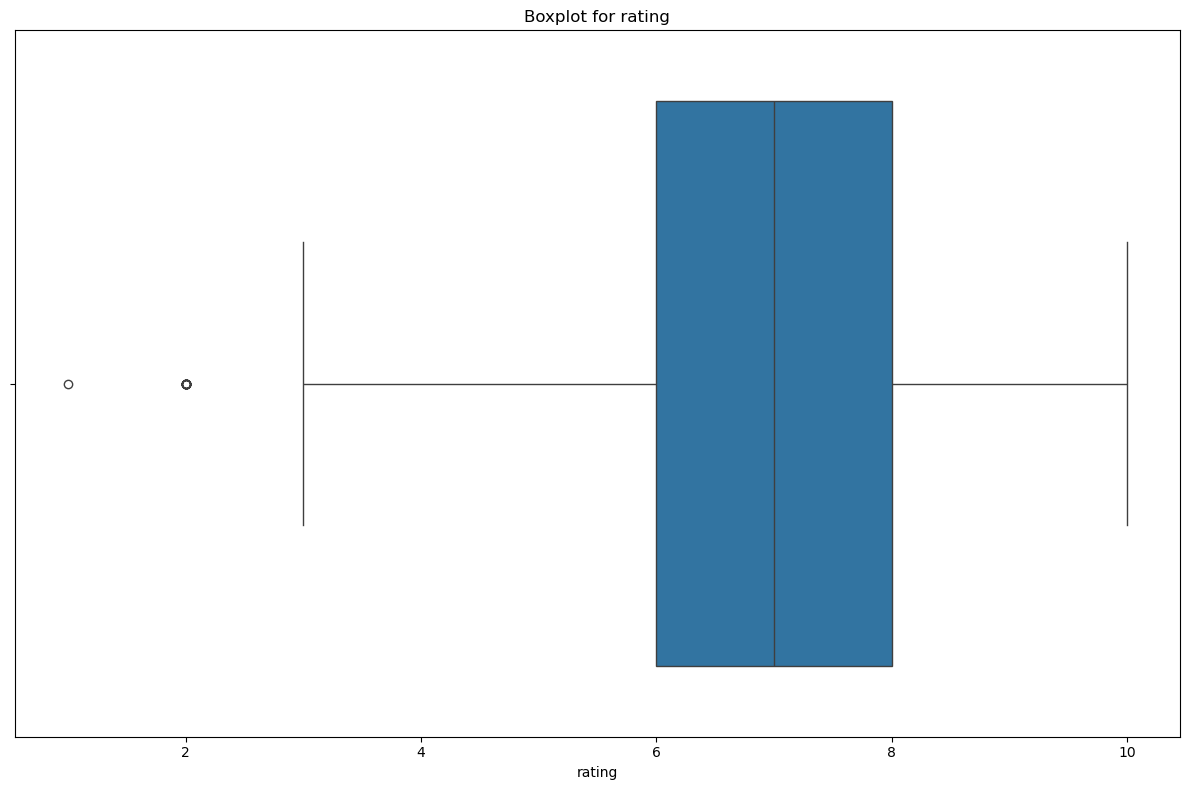

Outlier examples (titleType):
      titleType  rating
530       movie       2
662   tvEpisode       2
766       short       2
951       video       2
1169      movie       2

Analyzing group: movie
Group 'movie': 241 outliers detected (12.84% of group)

Analyzing group: short
Group 'short': 6 outliers detected (0.78% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 77 outliers detected (4.82% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 7 outliers detected (8.64% of group)

Analyzing group: tvMovie
Group 'tvMovie': 1 outliers detected (0.33% of group)

Analyzing group: tvSeries
Group 'tvSeries': 52 outliers detected (11.63% of group)

Analyzing group: tvShort
Group 'tvShort': 0 outliers detected (0.00% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 1 outliers detected (2.04% of group)

Analyzing group: video
Group 'video': 2 outliers detected (0.80% of group)

Analyzing group: videoGame
Group 'videoGame': 7 outliers detected (7.45% of group)

Total o

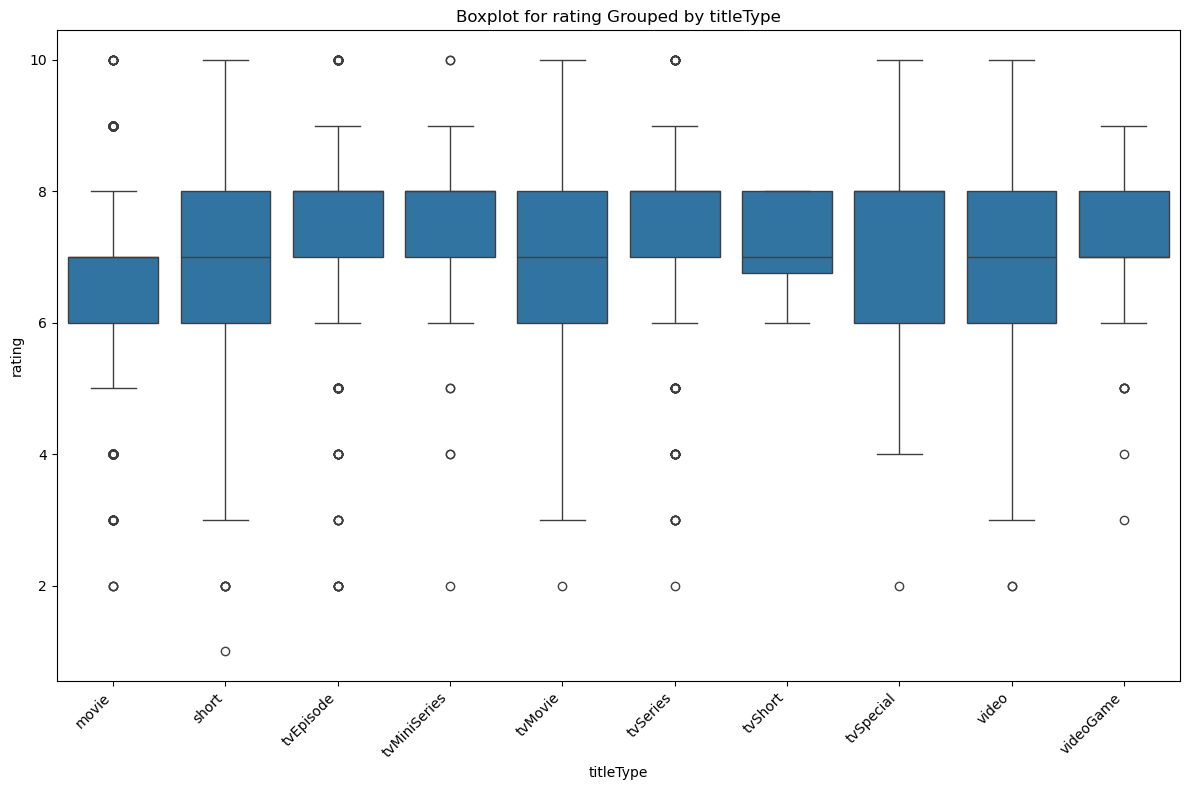

In [131]:
calculate_outliers(data_train, "rating")
calculate_outliers(data_train, "rating", group_by="titleType")

# runtimeMinutes


Analyzing column: runtimeMinutes
IQR: Q1=30.00, Q3=91.00, IQR=61.00
Total outliers detected: 36 (0.66% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



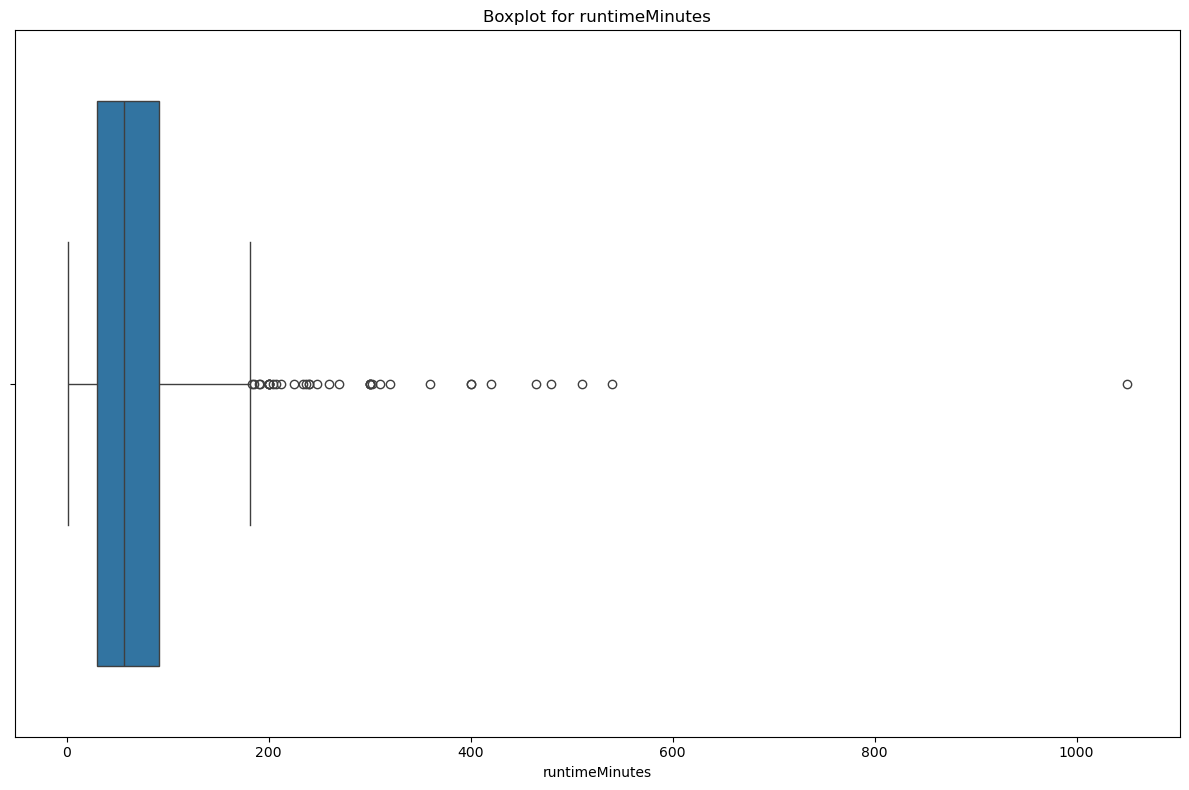

Outlier examples (titleType):
        titleType  runtimeMinutes
72          video           204.0
313       tvMovie           200.0
450         movie           200.0
469  tvMiniSeries           400.0
549      tvSeries           540.0

Analyzing group: movie
Group 'movie': 292 outliers detected (15.56% of group)

Analyzing group: short
Group 'short': 48 outliers detected (6.27% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 97 outliers detected (6.07% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 33 outliers detected (40.74% of group)

Analyzing group: tvMovie
Group 'tvMovie': 44 outliers detected (14.72% of group)

Analyzing group: tvSeries
Group 'tvSeries': 158 outliers detected (35.35% of group)

Analyzing group: tvShort
Group 'tvShort': 1 outliers detected (6.25% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 24 outliers detected (48.98% of group)

Analyzing group: video
Group 'video': 30 outliers detected (12.00% of group)

Analyzing group: vide

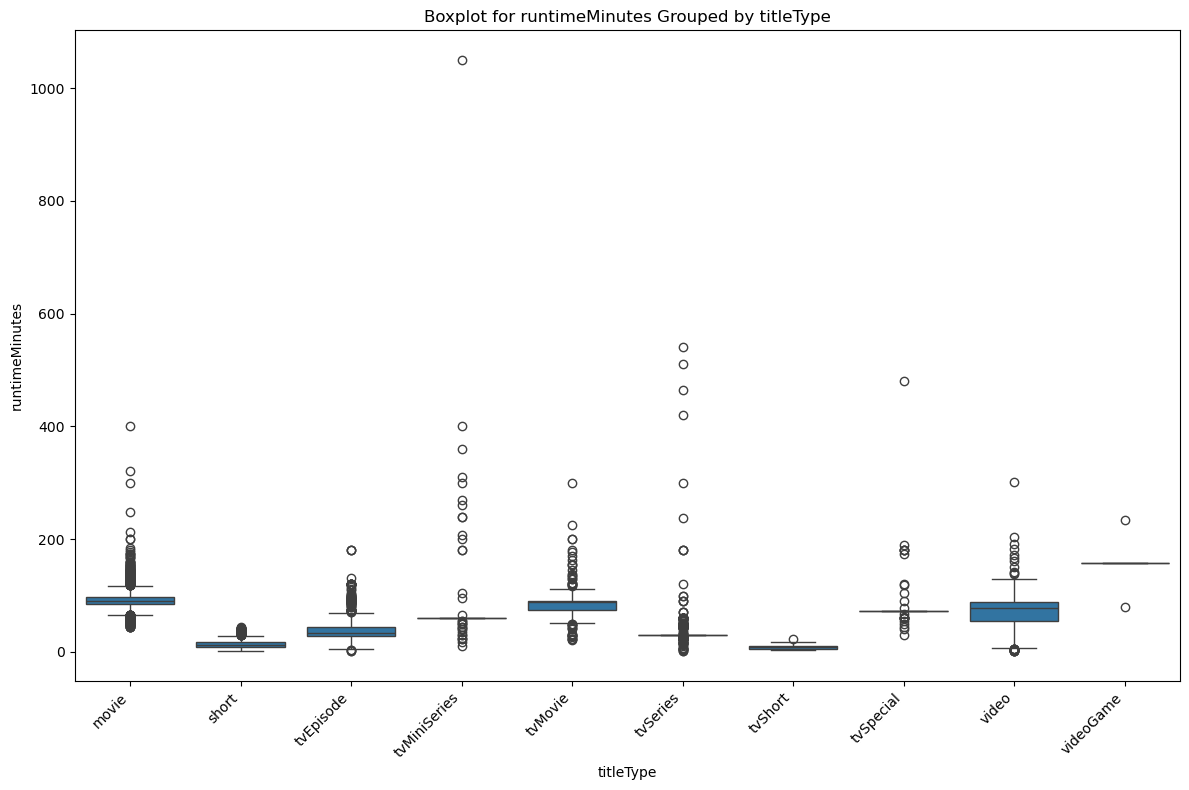

In [132]:
calculate_outliers(data_train, "runtimeMinutes")
calculate_outliers(data_train, "runtimeMinutes", group_by="titleType")

# awardWins


Analyzing column: awardWins
IQR: Q1=0.00, Q3=0.00, IQR=0.00
Total outliers detected: 570 (10.41% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



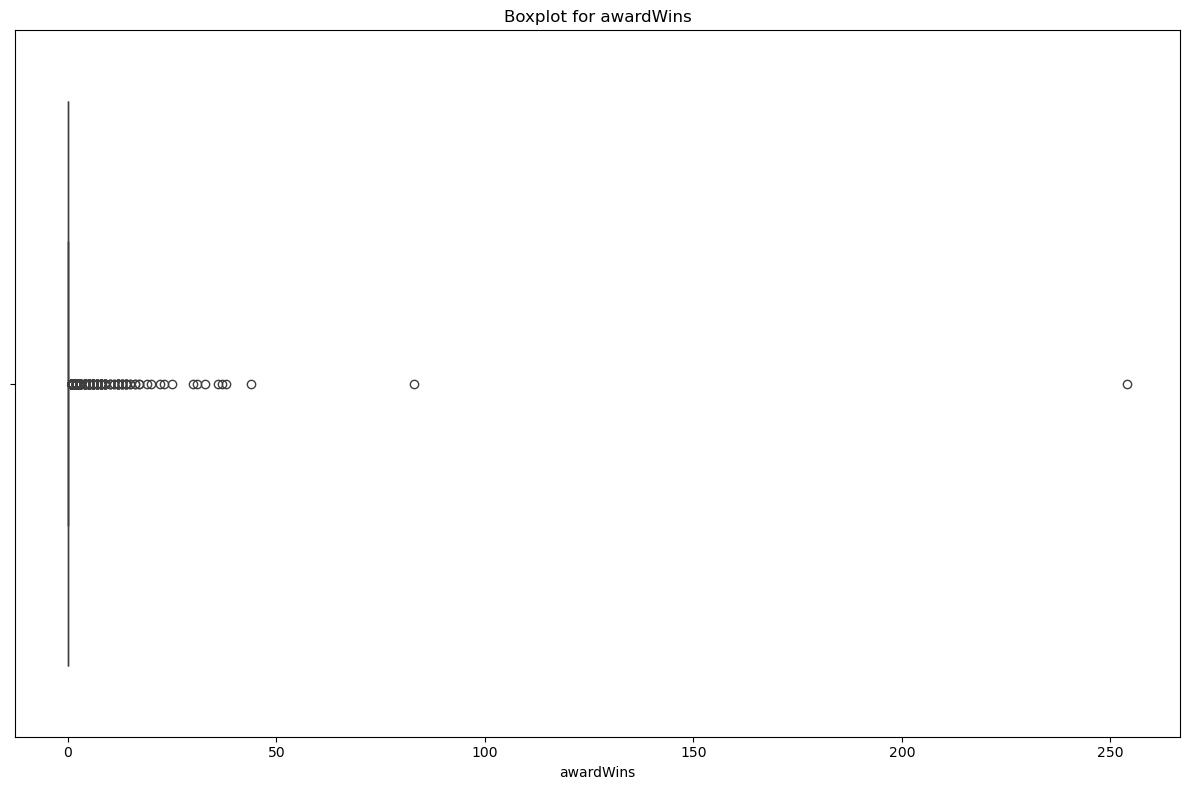

Outlier examples (titleType):
   titleType  awardWins
13     video        1.0
31     movie        1.0
42     movie        6.0
55     movie       16.0
73     short        1.0

Analyzing group: movie
Group 'movie': 334 outliers detected (17.79% of group)

Analyzing group: short
Group 'short': 121 outliers detected (15.80% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 3 outliers detected (0.19% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 9 outliers detected (11.11% of group)

Analyzing group: tvMovie
Group 'tvMovie': 17 outliers detected (5.69% of group)

Analyzing group: tvSeries
Group 'tvSeries': 64 outliers detected (14.32% of group)

Analyzing group: tvShort
Group 'tvShort': 3 outliers detected (18.75% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 5 outliers detected (10.20% of group)

Analyzing group: video
Group 'video': 10 outliers detected (4.00% of group)

Analyzing group: videoGame
Group 'videoGame': 4 outliers detected (4.26% of group)



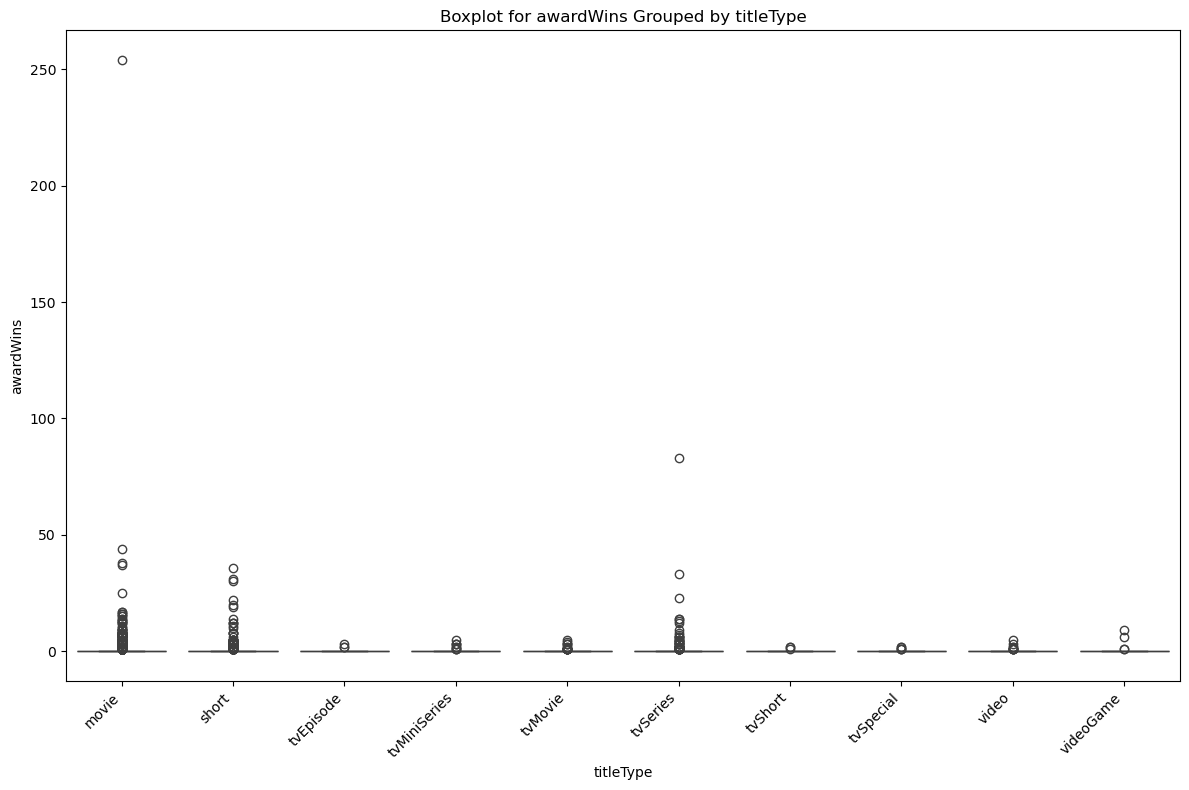

In [133]:
calculate_outliers(data_train, "awardWins")
calculate_outliers(data_train, "awardWins", group_by="titleType")

# numVotes


Analyzing column: numVotes
IQR: Q1=14.00, Q3=145.00, IQR=131.00
Total outliers detected: 840 (15.33% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



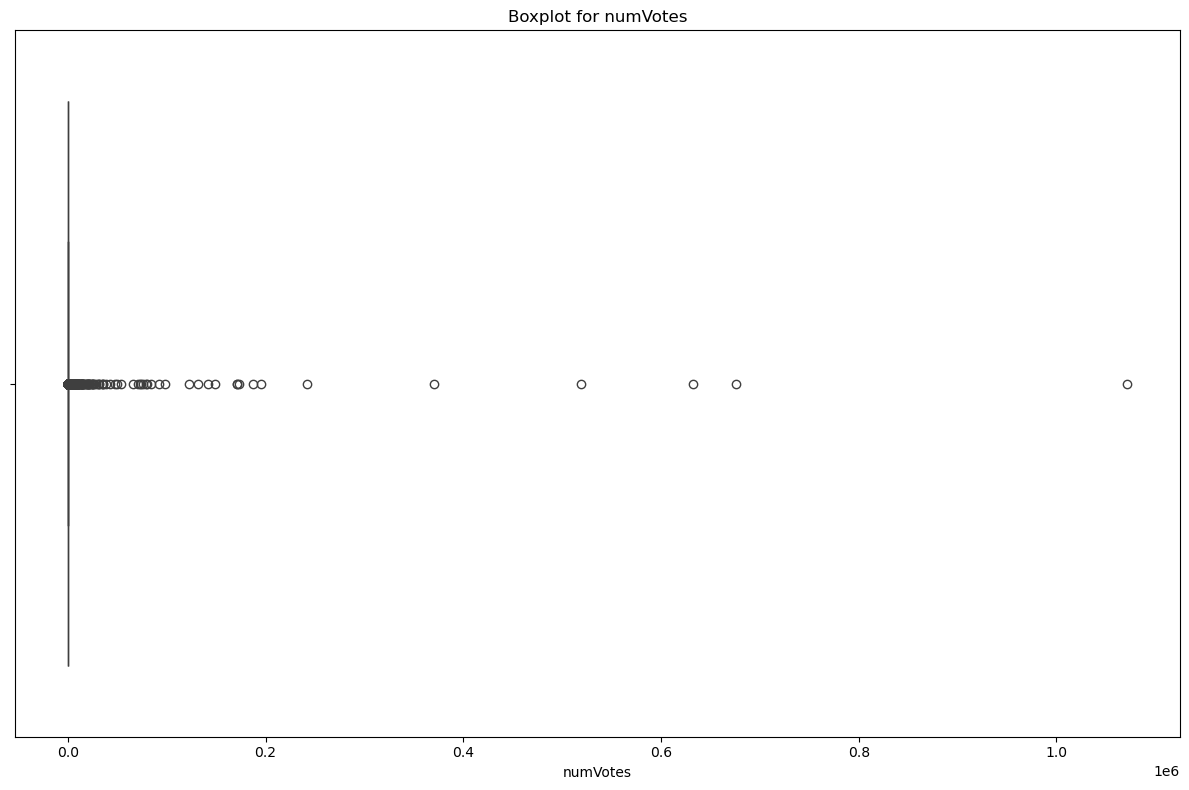

Outlier examples (titleType):
   titleType  numVotes
6   tvSeries       521
8      movie       769
9      short       376
31     movie      1730
33     movie       815

Analyzing group: movie
Group 'movie': 282 outliers detected (15.02% of group)

Analyzing group: short
Group 'short': 105 outliers detected (13.71% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 222 outliers detected (13.88% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 14 outliers detected (17.28% of group)

Analyzing group: tvMovie
Group 'tvMovie': 40 outliers detected (13.38% of group)

Analyzing group: tvSeries
Group 'tvSeries': 67 outliers detected (14.99% of group)

Analyzing group: tvShort
Group 'tvShort': 2 outliers detected (12.50% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 7 outliers detected (14.29% of group)

Analyzing group: video
Group 'video': 29 outliers detected (11.60% of group)

Analyzing group: videoGame
Group 'videoGame': 12 outliers detected (12.77% of group)

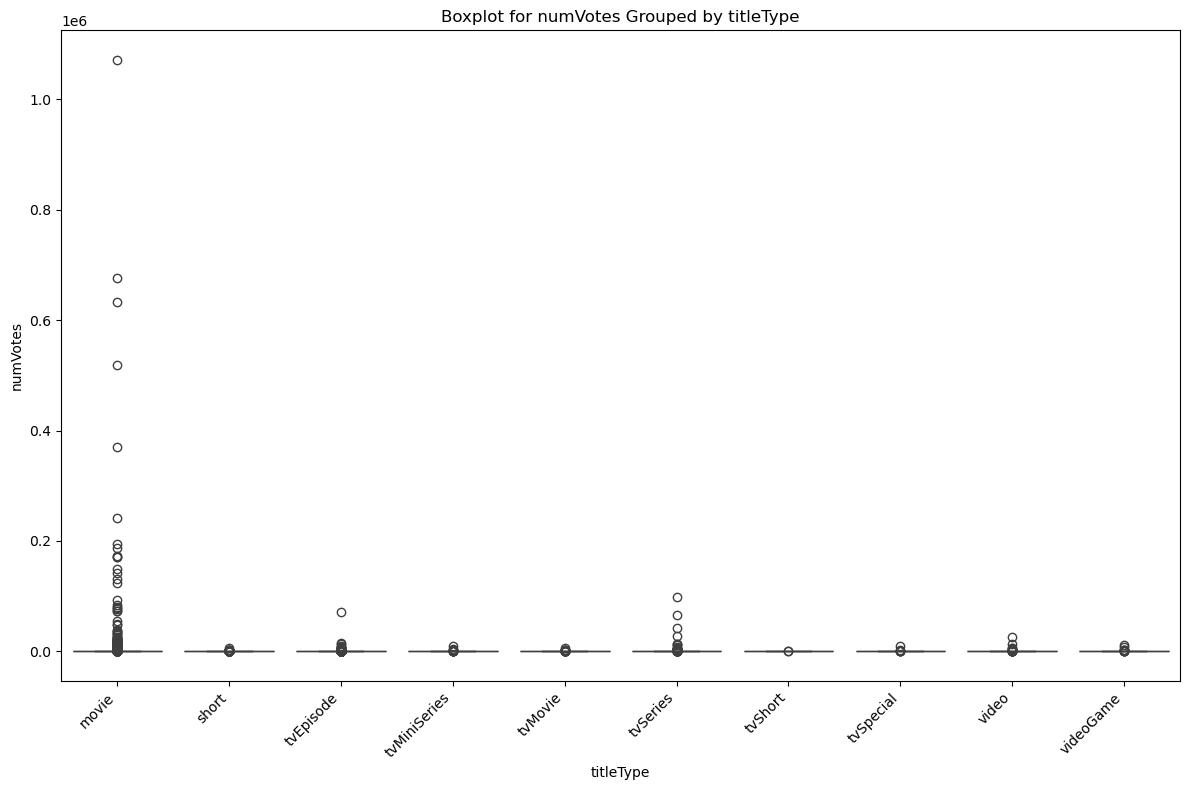

In [134]:
calculate_outliers(data_train, "numVotes")
calculate_outliers(data_train, "numVotes", group_by="titleType")


# numRegions


Analyzing column: numRegions
IQR: Q1=1.00, Q3=4.00, IQR=3.00
Total outliers detected: 530 (9.68% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



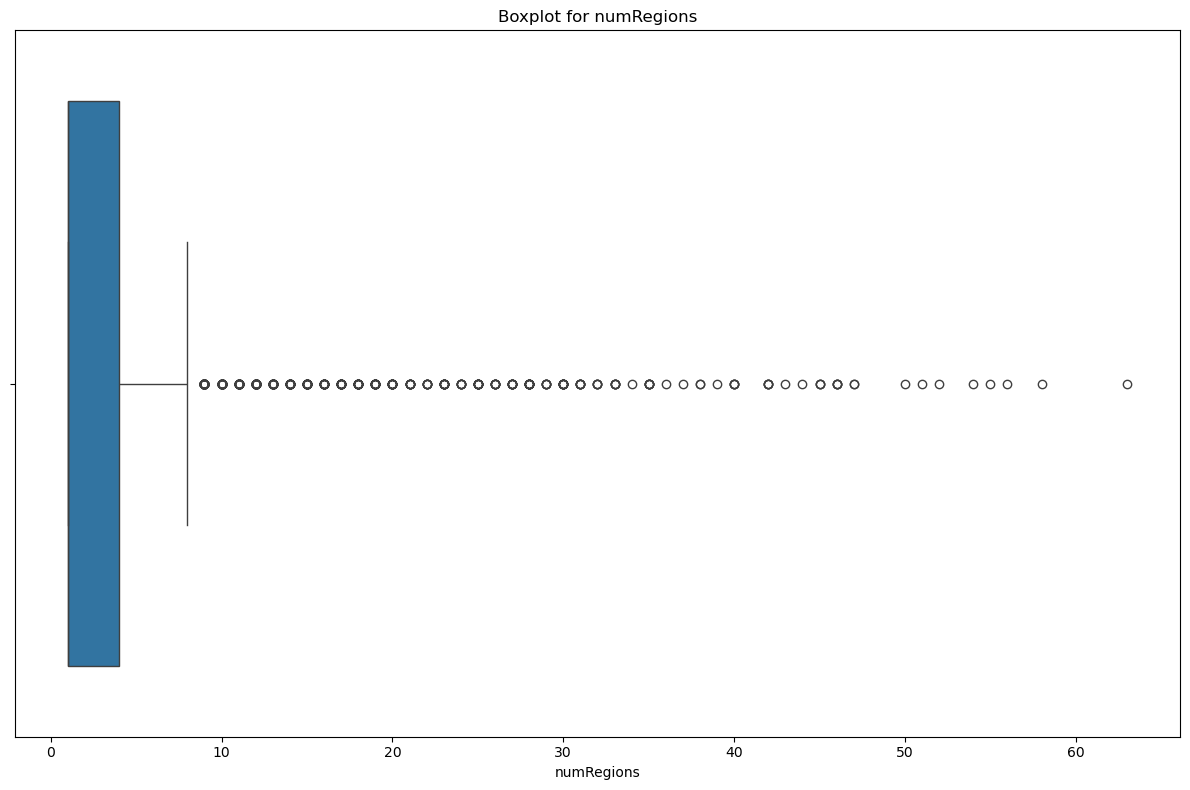

Outlier examples (titleType):
   titleType  numRegions
6   tvSeries          12
8      movie          15
33     movie          15
34     movie          16
42     movie          13

Analyzing group: movie
Group 'movie': 182 outliers detected (9.70% of group)

Analyzing group: short
Group 'short': 82 outliers detected (10.70% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 175 outliers detected (10.94% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 5 outliers detected (6.17% of group)

Analyzing group: tvMovie
Group 'tvMovie': 28 outliers detected (9.36% of group)

Analyzing group: tvSeries
Group 'tvSeries': 56 outliers detected (12.53% of group)

Analyzing group: tvShort
Group 'tvShort': 1 outliers detected (6.25% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 7 outliers detected (14.29% of group)

Analyzing group: video
Group 'video': 32 outliers detected (12.80% of group)

Analyzing group: videoGame
Group 'videoGame': 14 outliers detected (14.89% of 

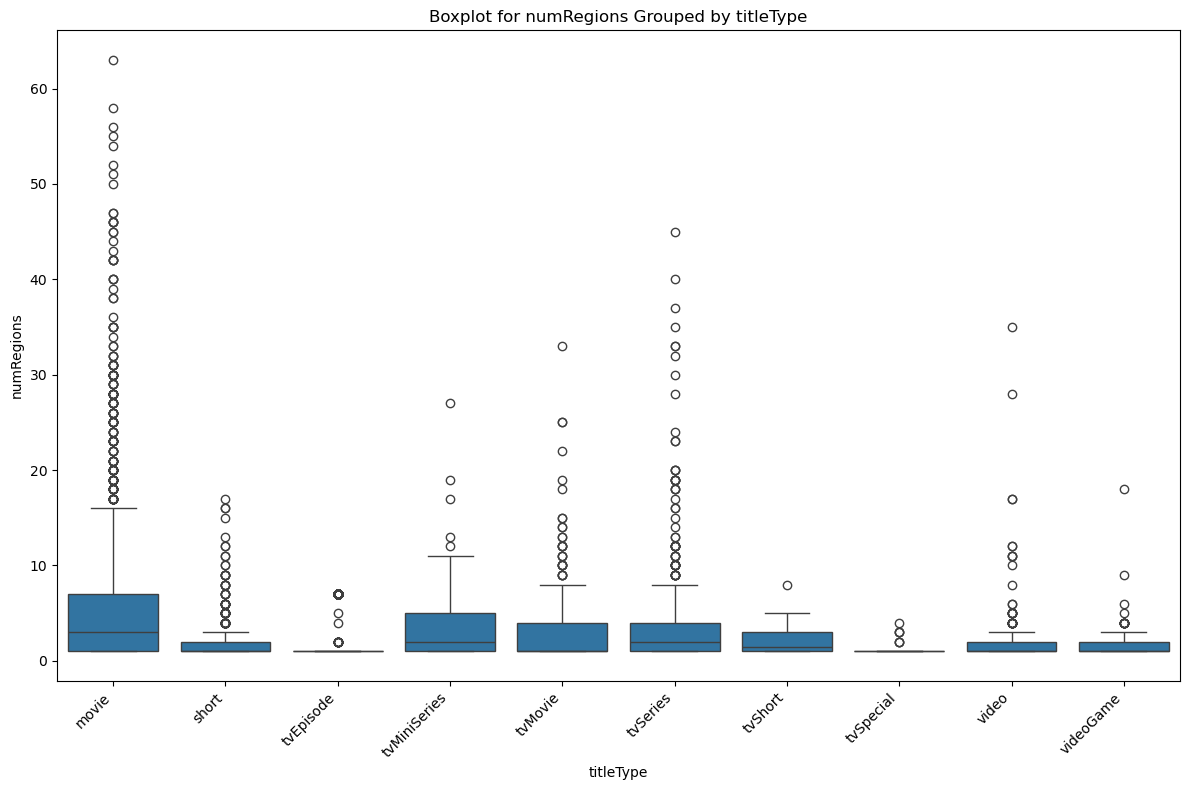

In [135]:
calculate_outliers(data_train, "numRegions")
calculate_outliers(data_train, "numRegions", group_by="titleType")


# totalImages


Analyzing column: totalImages
IQR: Q1=1.00, Q3=6.00, IQR=5.00
Total outliers detected: 766 (13.98% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



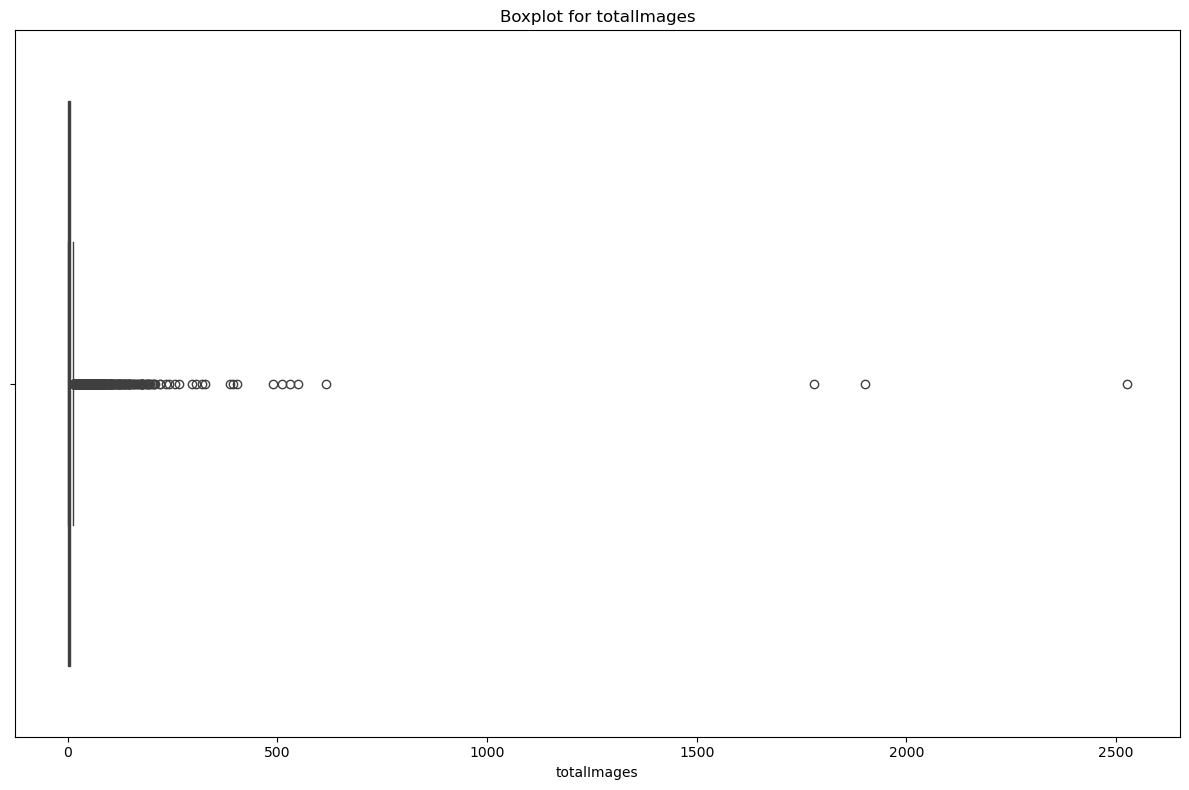

Outlier examples (titleType):
   titleType  totalImages
6   tvSeries           14
8      movie           28
10     movie           22
34     movie           23
35     movie           61

Analyzing group: movie
Group 'movie': 251 outliers detected (13.37% of group)

Analyzing group: short
Group 'short': 84 outliers detected (10.97% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 203 outliers detected (12.70% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 9 outliers detected (11.11% of group)

Analyzing group: tvMovie
Group 'tvMovie': 35 outliers detected (11.71% of group)

Analyzing group: tvSeries
Group 'tvSeries': 62 outliers detected (13.87% of group)

Analyzing group: tvShort
Group 'tvShort': 1 outliers detected (6.25% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 9 outliers detected (18.37% of group)

Analyzing group: video
Group 'video': 22 outliers detected (8.80% of group)

Analyzing group: videoGame
Group 'videoGame': 10 outliers detected (10

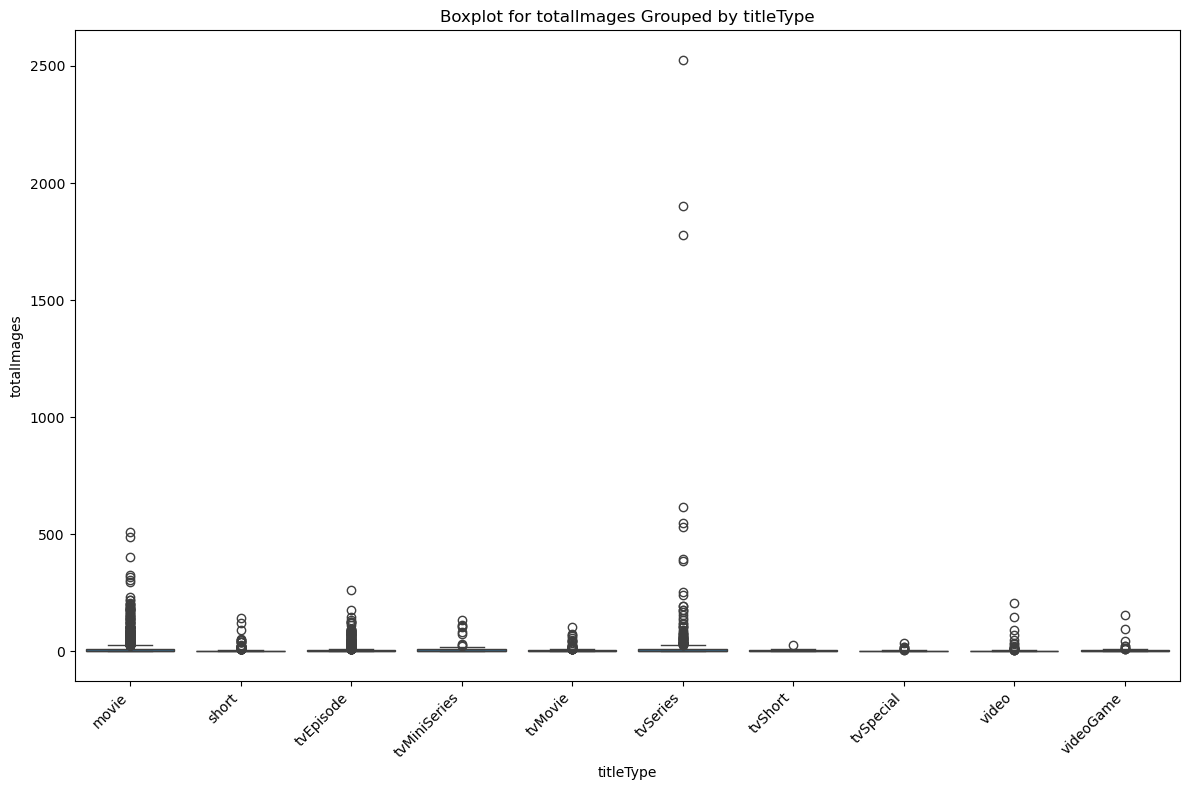

In [136]:
calculate_outliers(data_train, "totalImages")
calculate_outliers(data_train, "totalImages", group_by="titleType")

# totalVideos


Analyzing column: totalVideos
IQR: Q1=0.00, Q3=0.00, IQR=0.00
Total outliers detected: 486 (8.87% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



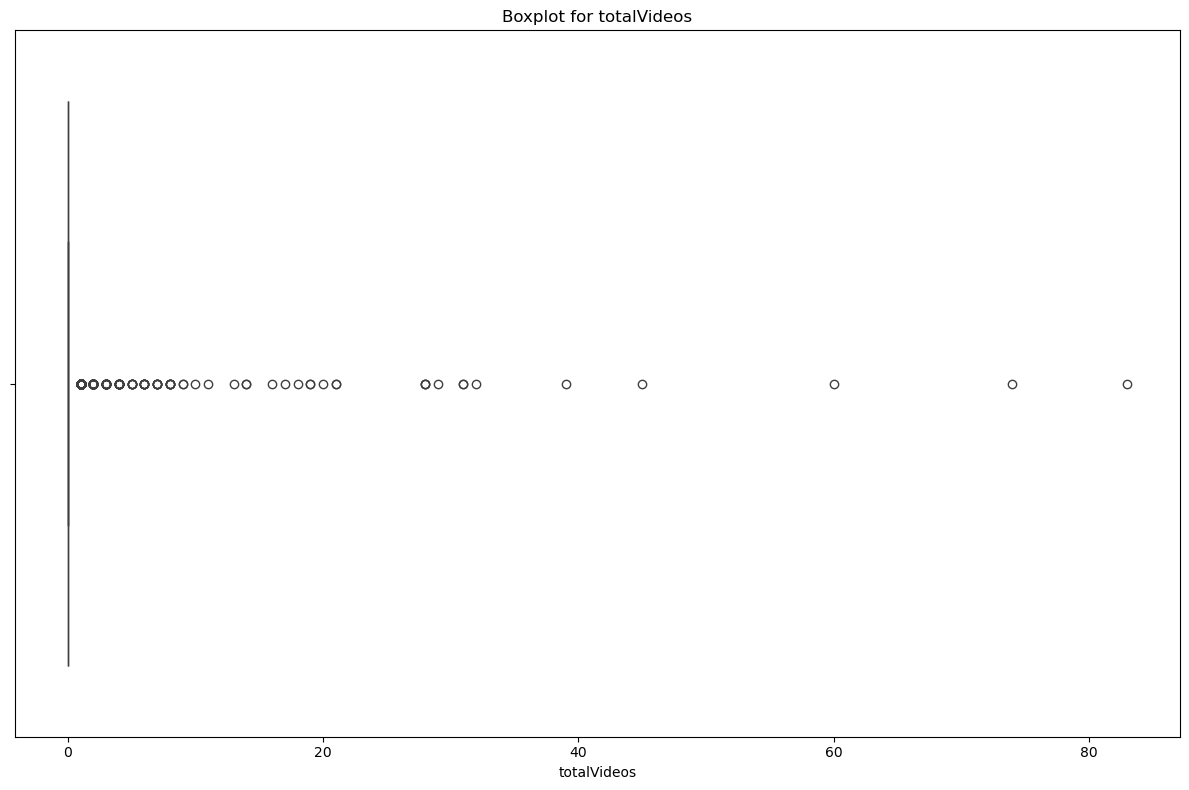

Outlier examples (titleType):
   titleType  totalVideos
0      video            2
15     movie            1
33     movie            1
47     short            1
55     movie           28

Analyzing group: movie
Group 'movie': 328 outliers detected (17.47% of group)

Analyzing group: short
Group 'short': 32 outliers detected (4.18% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 39 outliers detected (2.44% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 10 outliers detected (12.35% of group)

Analyzing group: tvMovie
Group 'tvMovie': 8 outliers detected (2.68% of group)

Analyzing group: tvSeries
Group 'tvSeries': 41 outliers detected (9.17% of group)

Analyzing group: tvShort
Group 'tvShort': 0 outliers detected (0.00% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 2 outliers detected (4.08% of group)

Analyzing group: video
Group 'video': 11 outliers detected (4.40% of group)

Analyzing group: videoGame
Group 'videoGame': 15 outliers detected (15.96% o

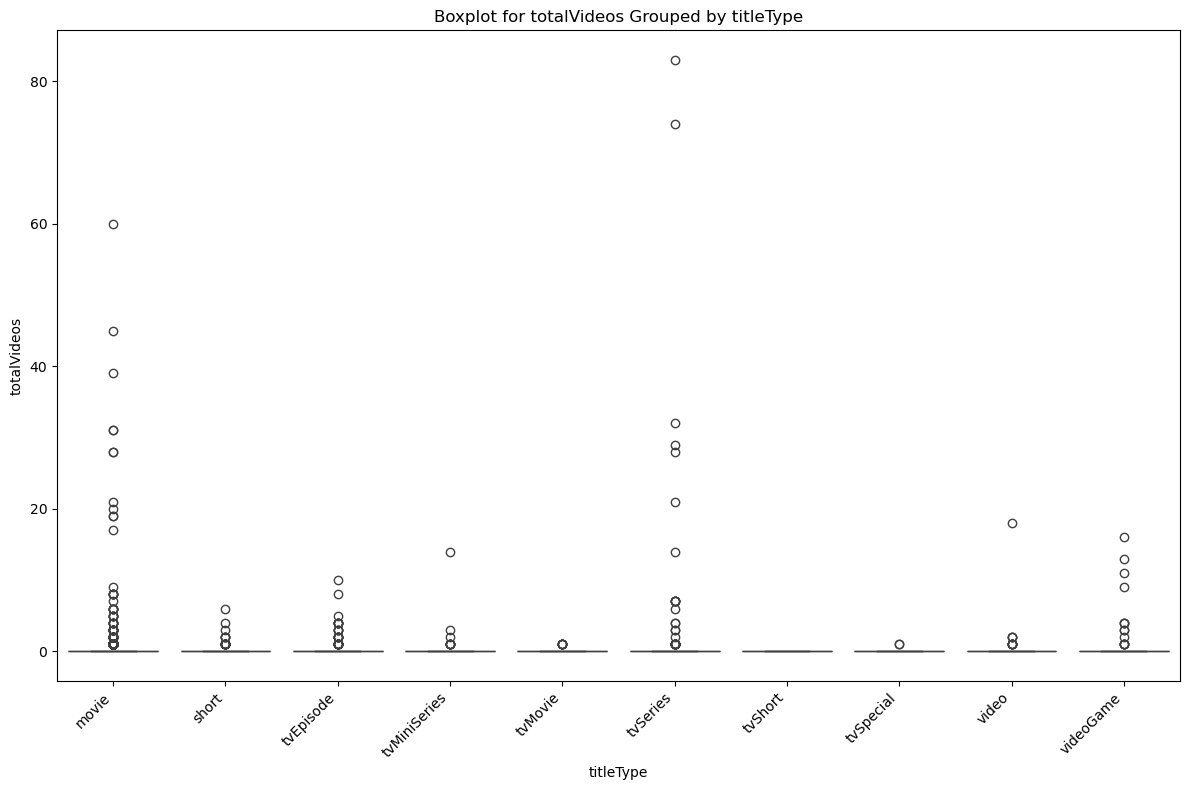

In [137]:
calculate_outliers(data_train, "totalVideos")
calculate_outliers(data_train, "totalVideos", group_by="titleType")


# totalCredits


Analyzing column: totalCredits
IQR: Q1=16.00, Q3=65.00, IQR=49.00
Total outliers detected: 476 (8.69% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



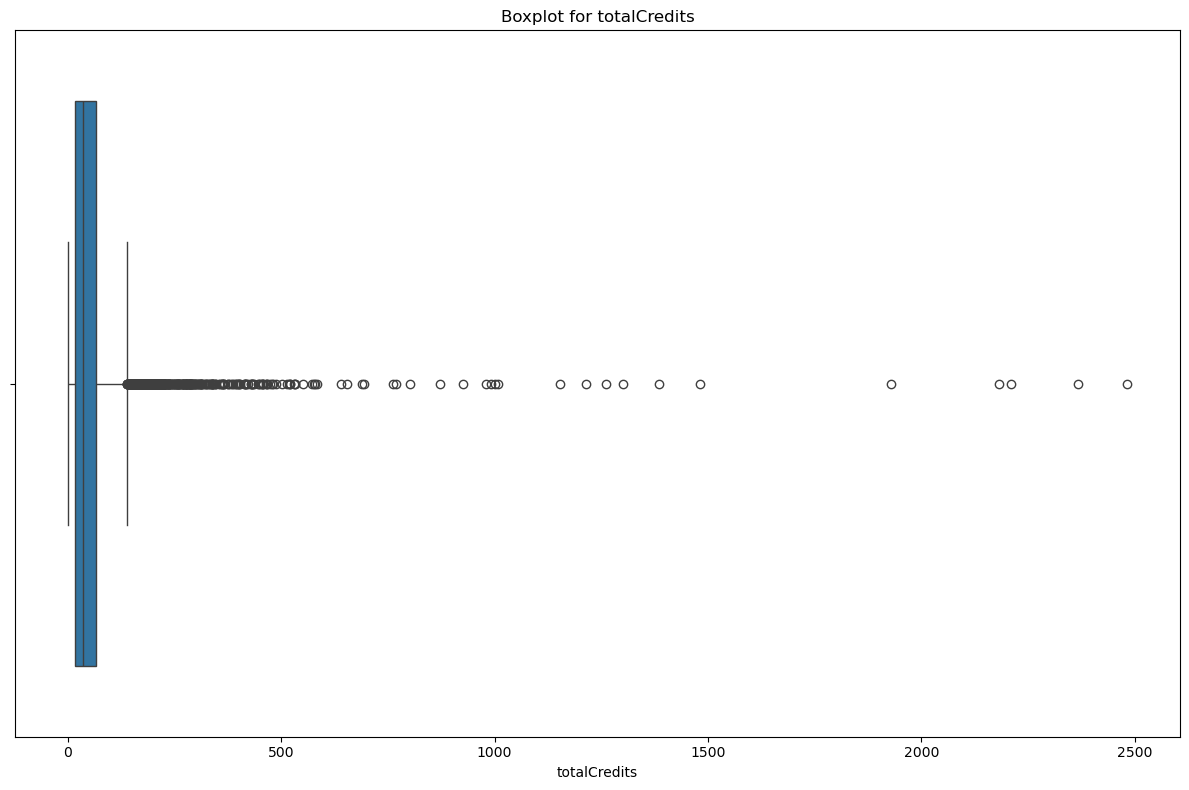

Outlier examples (titleType):
   titleType  totalCredits
11     movie           236
15     movie           188
18  tvSeries           190
45  tvSeries          2482
55     movie           313

Analyzing group: movie
Group 'movie': 168 outliers detected (8.95% of group)

Analyzing group: short
Group 'short': 48 outliers detected (6.27% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 134 outliers detected (8.38% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 4 outliers detected (4.94% of group)

Analyzing group: tvMovie
Group 'tvMovie': 12 outliers detected (4.01% of group)

Analyzing group: tvSeries
Group 'tvSeries': 44 outliers detected (9.84% of group)

Analyzing group: tvShort
Group 'tvShort': 2 outliers detected (12.50% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 2 outliers detected (4.08% of group)

Analyzing group: video
Group 'video': 25 outliers detected (10.00% of group)

Analyzing group: videoGame
Group 'videoGame': 7 outliers detected (7.

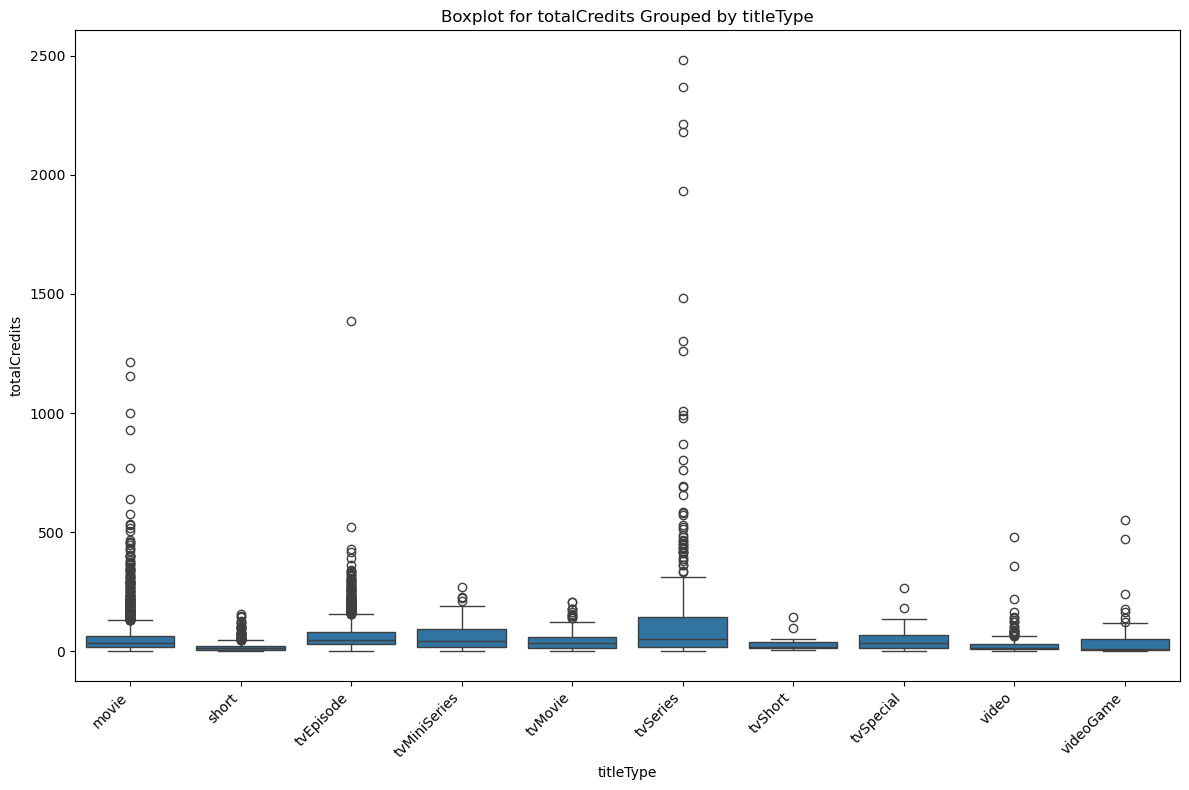

In [138]:
calculate_outliers(data_train, "totalCredits")
calculate_outliers(data_train, "totalCredits", group_by="titleType")


# criticReviewsTotal


Analyzing column: criticReviewsTotal
IQR: Q1=0.00, Q3=1.00, IQR=1.00
Total outliers detected: 796 (14.53% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



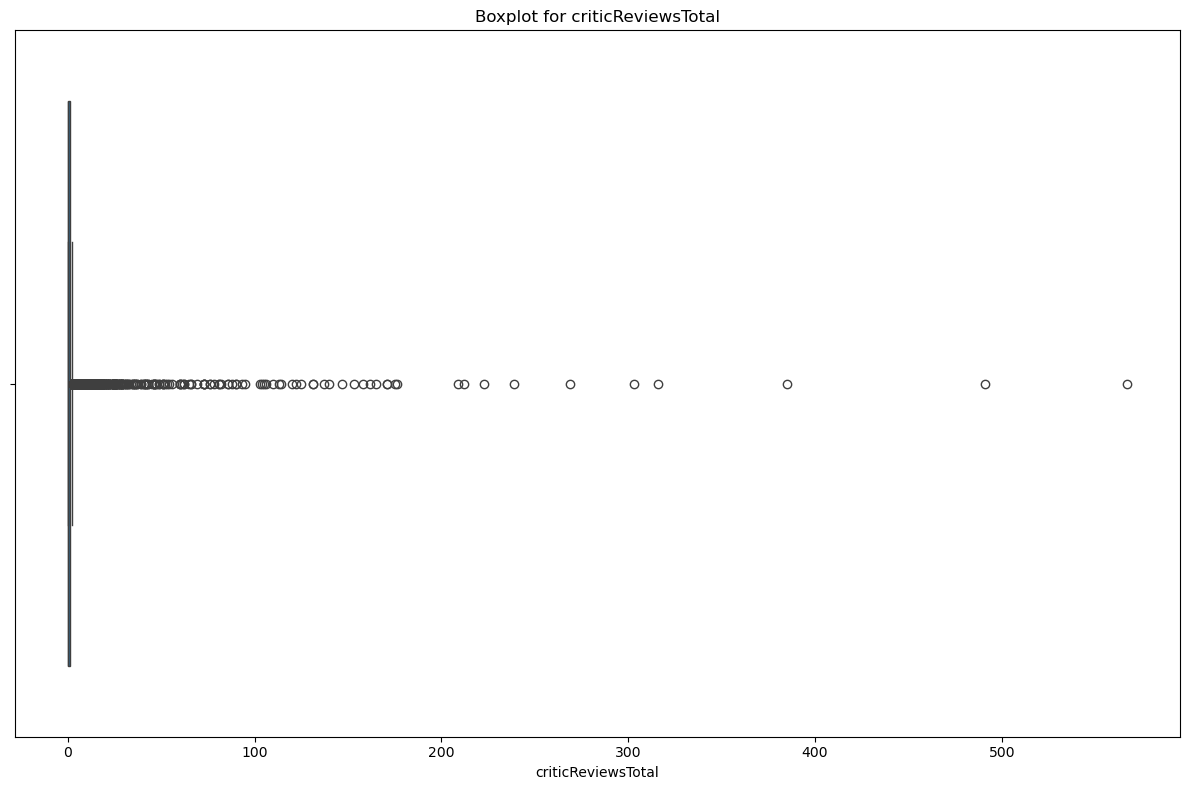

Outlier examples (titleType):
   titleType  criticReviewsTotal
1      movie                   9
31     movie                   3
33     movie                   7
34     movie                   7
42     movie                   7

Analyzing group: movie
Group 'movie': 316 outliers detected (16.84% of group)

Analyzing group: short
Group 'short': 122 outliers detected (15.93% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 361 outliers detected (22.58% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 14 outliers detected (17.28% of group)

Analyzing group: tvMovie
Group 'tvMovie': 33 outliers detected (11.04% of group)

Analyzing group: tvSeries
Group 'tvSeries': 73 outliers detected (16.33% of group)

Analyzing group: tvShort
Group 'tvShort': 3 outliers detected (18.75% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 3 outliers detected (6.12% of group)

Analyzing group: video
Group 'video': 40 outliers detected (16.00% of group)

Analyzing group: videoGam

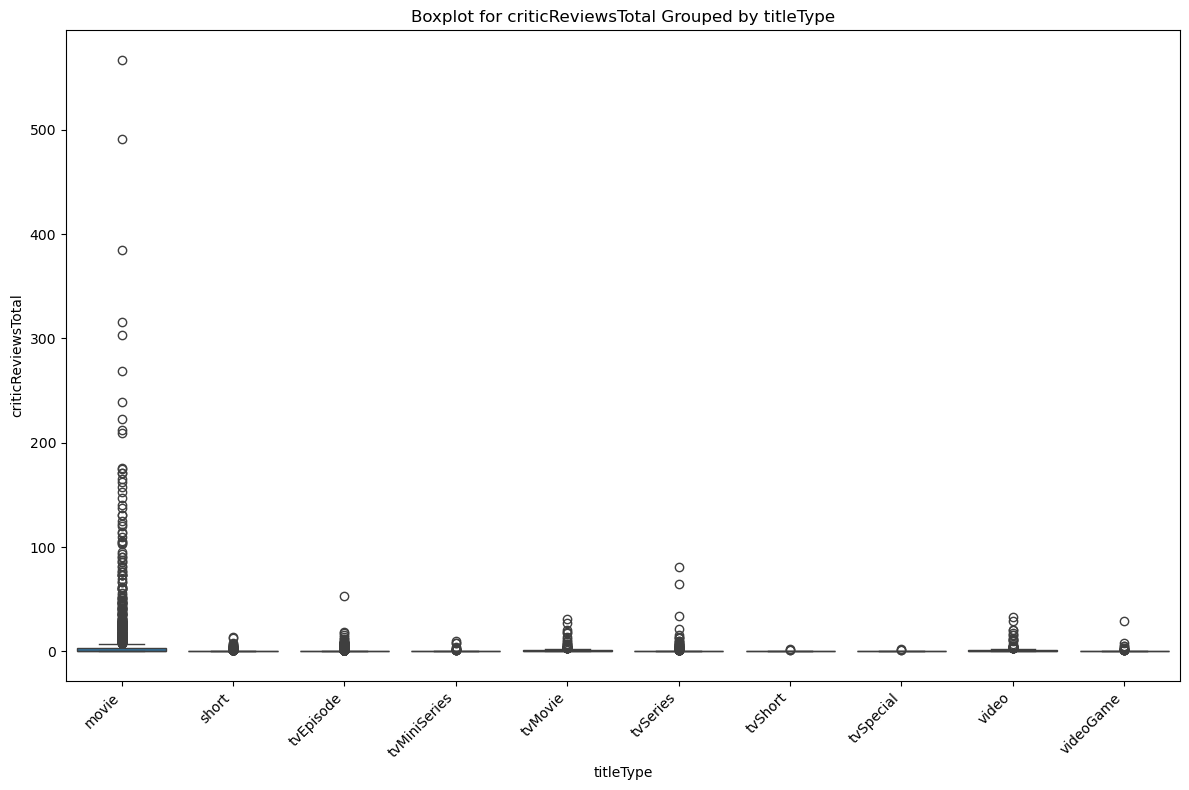

In [139]:
calculate_outliers(data_train, "criticReviewsTotal")
calculate_outliers(data_train, "criticReviewsTotal", group_by="titleType")

# awardNominationsExcludeWins


Analyzing column: awardNominationsExcludeWins
IQR: Q1=0.00, Q3=0.00, IQR=0.00
Total outliers detected: 682 (12.45% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



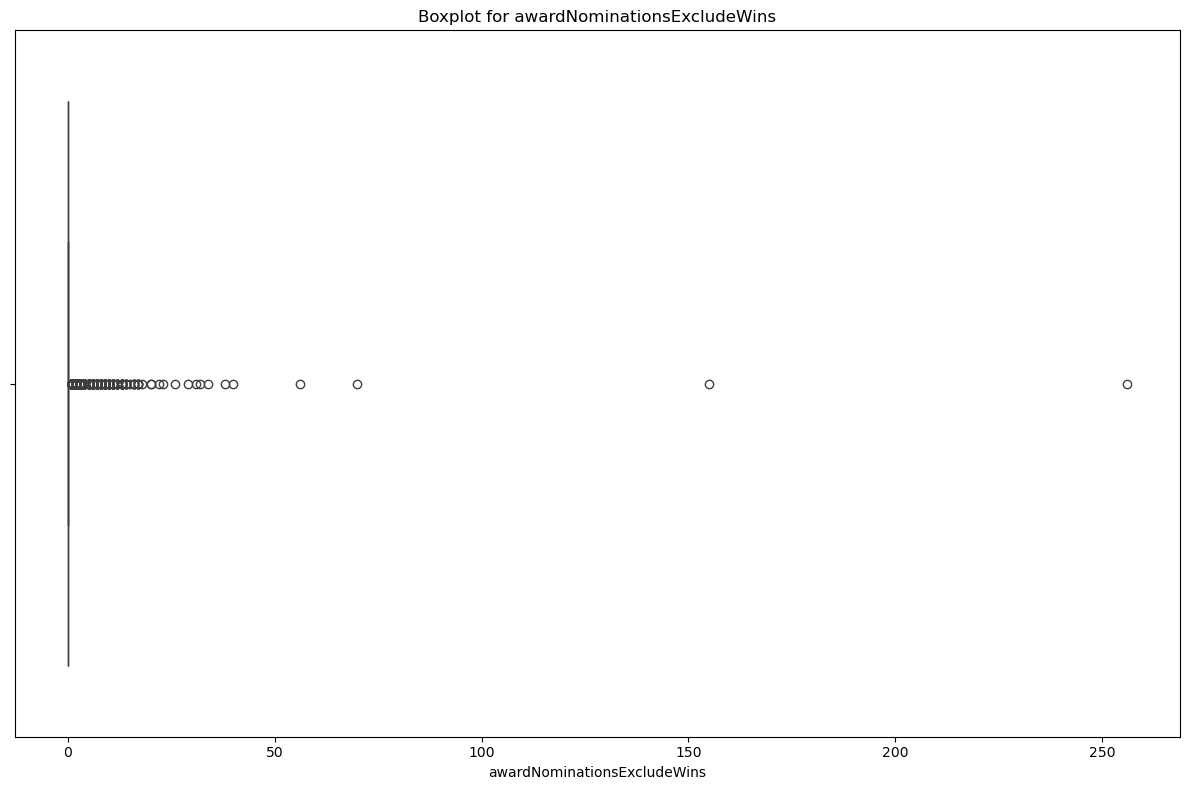

Outlier examples (titleType):
   titleType  awardNominationsExcludeWins
11     movie                            1
31     movie                            5
42     movie                           12
47     short                            2
55     movie                           20

Analyzing group: movie
Group 'movie': 401 outliers detected (21.36% of group)

Analyzing group: short
Group 'short': 112 outliers detected (14.62% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 6 outliers detected (0.38% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 10 outliers detected (12.35% of group)

Analyzing group: tvMovie
Group 'tvMovie': 34 outliers detected (11.37% of group)

Analyzing group: tvSeries
Group 'tvSeries': 87 outliers detected (19.46% of group)

Analyzing group: tvShort
Group 'tvShort': 4 outliers detected (25.00% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 9 outliers detected (18.37% of group)

Analyzing group: video
Group 'video': 9 outliers de

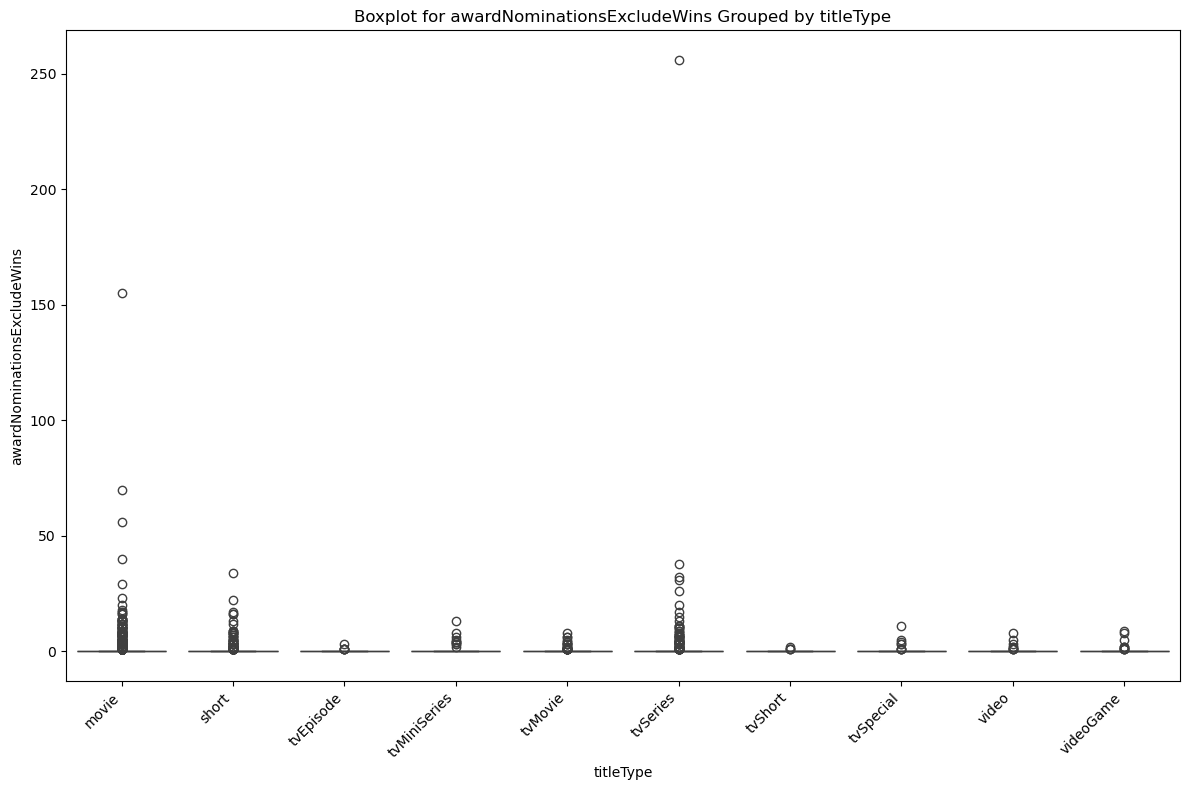

In [140]:
calculate_outliers(data_train, "awardNominationsExcludeWins")
calculate_outliers(data_train, "awardNominationsExcludeWins", group_by="titleType")


# userReviewsTotal



Analyzing column: userReviewsTotal
IQR: Q1=0.00, Q3=2.00, IQR=2.00
Total outliers detected: 702 (12.81% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



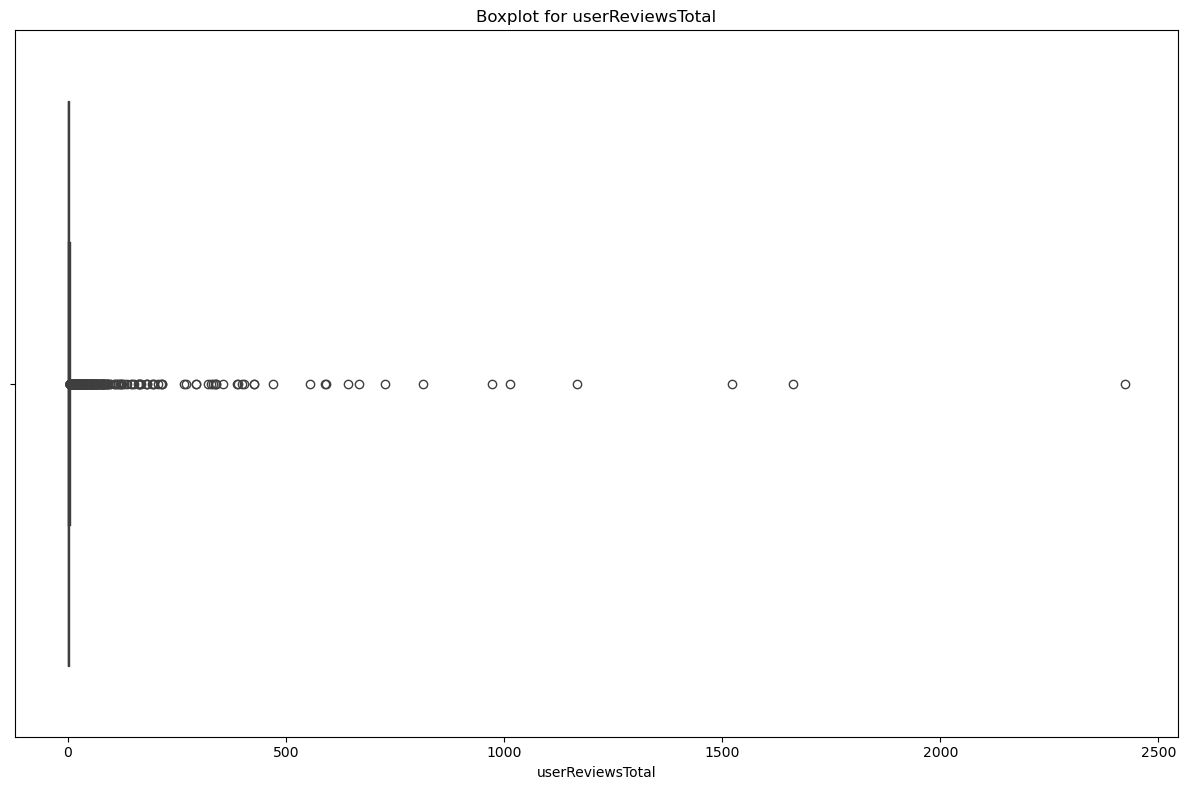

Outlier examples (titleType):
   titleType  userReviewsTotal
1      movie                 8
6   tvSeries                 6
8      movie                 8
11     movie                 6
30     movie                 6

Analyzing group: movie
Group 'movie': 260 outliers detected (13.85% of group)

Analyzing group: short
Group 'short': 102 outliers detected (13.32% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 231 outliers detected (14.45% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 11 outliers detected (13.58% of group)

Analyzing group: tvMovie
Group 'tvMovie': 42 outliers detected (14.05% of group)

Analyzing group: tvSeries
Group 'tvSeries': 66 outliers detected (14.77% of group)

Analyzing group: tvShort
Group 'tvShort': 3 outliers detected (18.75% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 4 outliers detected (8.16% of group)

Analyzing group: video
Group 'video': 35 outliers detected (14.00% of group)

Analyzing group: videoGame
Group 'vid

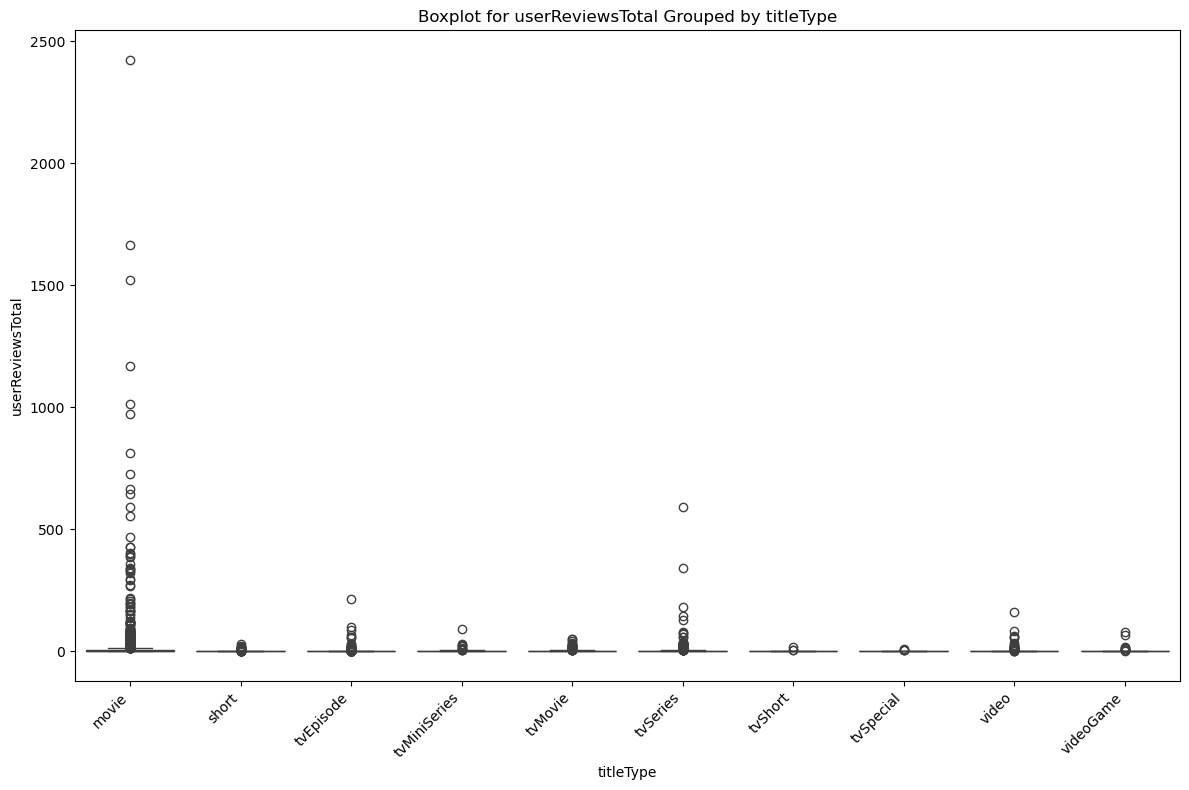

In [141]:
calculate_outliers(data_train, "userReviewsTotal")
calculate_outliers(data_train, "userReviewsTotal", group_by="titleType")

# NumberOfCountryoforigin


Analyzing column: NumberOfCountryoforigin
IQR: Q1=1.00, Q3=1.00, IQR=0.00
Total outliers detected: 380 (6.94% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



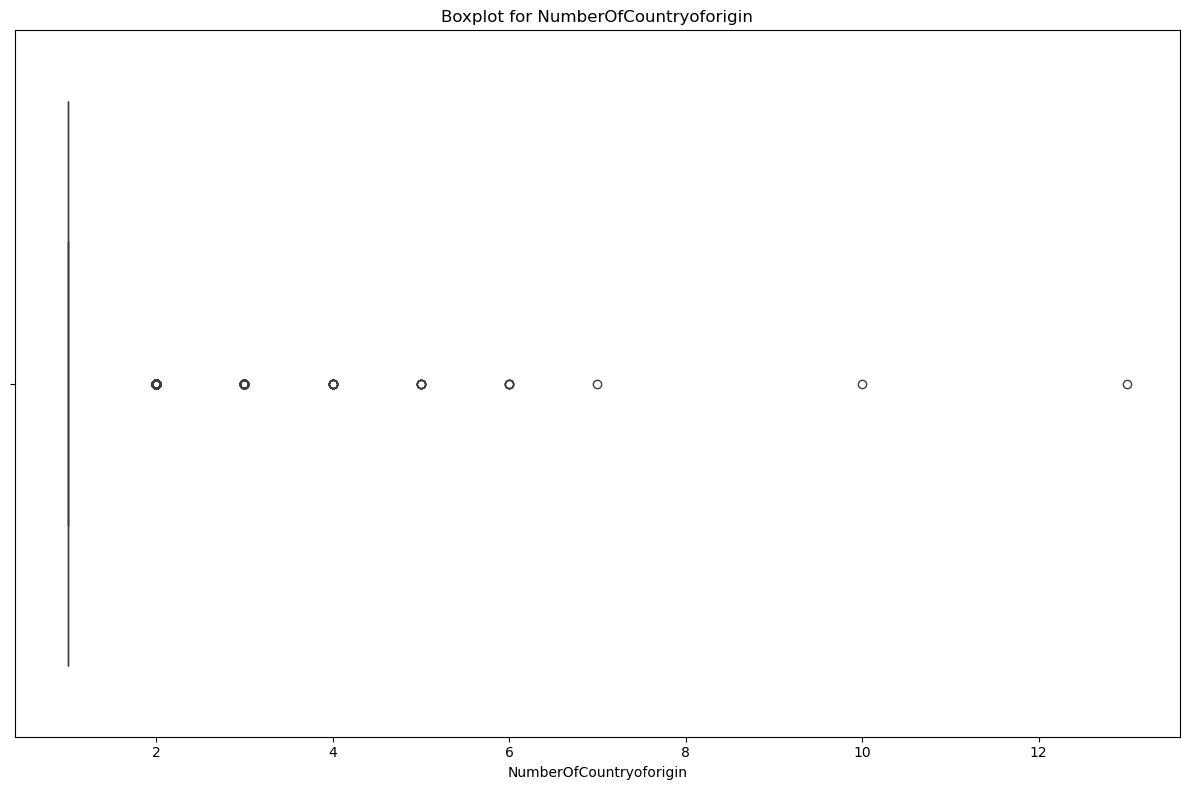

Outlier examples (titleType):
   titleType  NumberOfCountryoforigin
15     movie                        2
35     movie                        2
64  tvSeries                        2
65     movie                        2
78     movie                        4

Analyzing group: movie
Group 'movie': 214 outliers detected (11.40% of group)

Analyzing group: short
Group 'short': 32 outliers detected (4.18% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 65 outliers detected (4.07% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 3 outliers detected (3.70% of group)

Analyzing group: tvMovie
Group 'tvMovie': 23 outliers detected (7.69% of group)

Analyzing group: tvSeries
Group 'tvSeries': 18 outliers detected (4.03% of group)

Analyzing group: tvShort
Group 'tvShort': 0 outliers detected (0.00% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 0 outliers detected (0.00% of group)

Analyzing group: video
Group 'video': 18 outliers detected (7.20% of group)

Analy

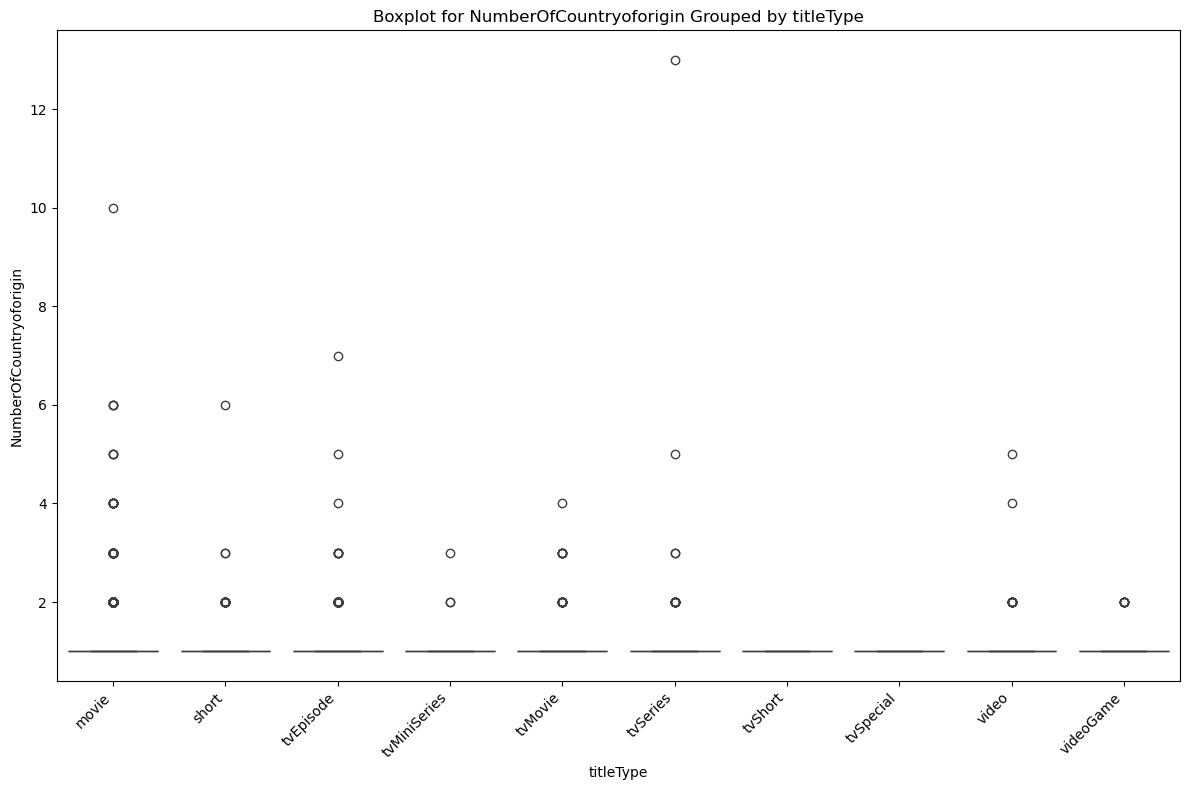

In [142]:
calculate_outliers(data_train, "NumberOfCountryoforigin")
calculate_outliers(data_train, "NumberOfCountryoforigin", group_by="titleType")

# nominations



Analyzing column: nominations
IQR: Q1=0.00, Q3=0.00, IQR=0.00
Total outliers detected: 837 (15.28% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



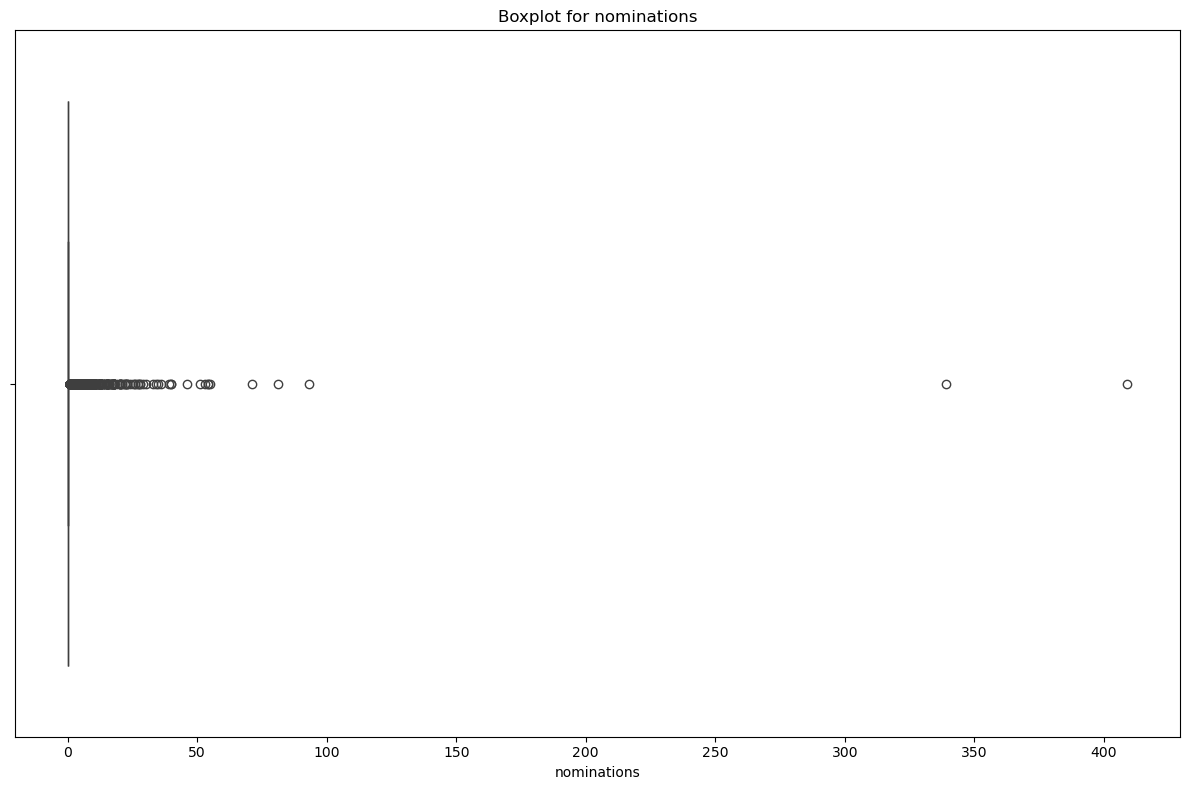

Outlier examples (titleType):
   titleType  nominations
13     video          1.0
31     movie          6.0
42     movie         18.0
47     short          2.0
55     movie         36.0

Analyzing group: movie
Group 'movie': 230 outliers detected (12.25% of group)

Analyzing group: short
Group 'short': 161 outliers detected (21.02% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 8 outliers detected (0.50% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 12 outliers detected (14.81% of group)

Analyzing group: tvMovie
Group 'tvMovie': 35 outliers detected (11.71% of group)

Analyzing group: tvSeries
Group 'tvSeries': 56 outliers detected (12.53% of group)

Analyzing group: tvShort
Group 'tvShort': 0 outliers detected (0.00% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 8 outliers detected (16.33% of group)

Analyzing group: video
Group 'video': 14 outliers detected (5.60% of group)

Analyzing group: videoGame
Group 'videoGame': 9 outliers detected (9.57

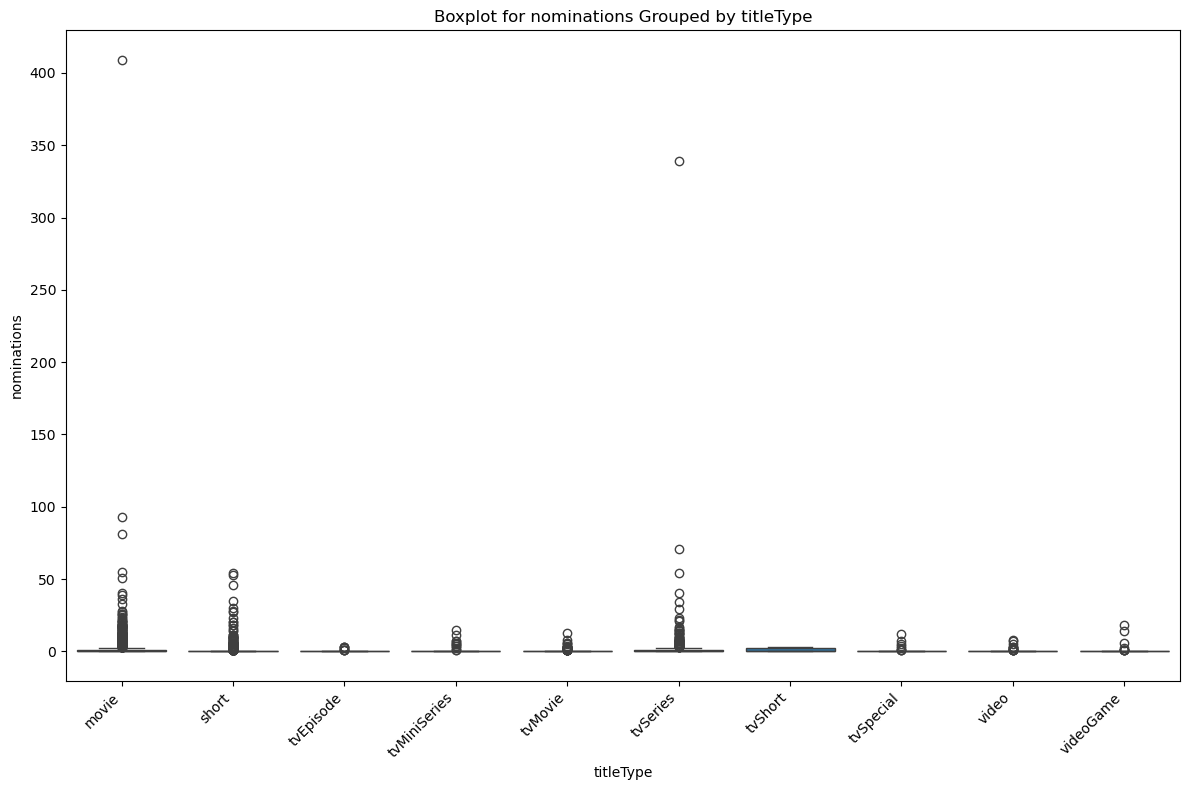

In [143]:
calculate_outliers(data_train, "nominations")
calculate_outliers(data_train, "nominations", group_by="titleType")


# NumberOfGenres


Analyzing column: NumberOfGenres
IQR: Q1=1.00, Q3=3.00, IQR=2.00
Total outliers detected: 0 (0.00% of total dataset)


/home/francesco/miniconda3/envs/datamining/lib/python3.9/site-packages/seaborn/_base.py:1608: UserWarning:

Vertical orientation ignored with only `x` specified.



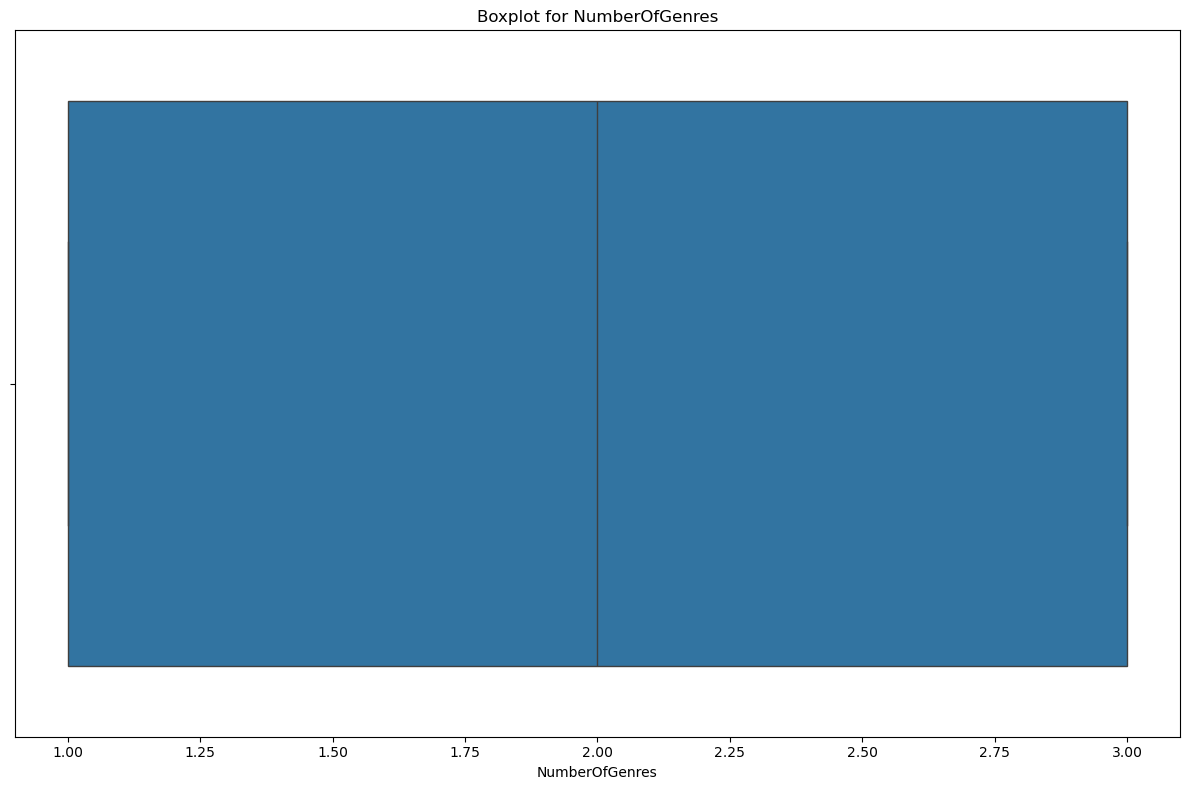


Analyzing group: movie
Group 'movie': 0 outliers detected (0.00% of group)

Analyzing group: short
Group 'short': 0 outliers detected (0.00% of group)

Analyzing group: tvEpisode
Group 'tvEpisode': 0 outliers detected (0.00% of group)

Analyzing group: tvMiniSeries
Group 'tvMiniSeries': 0 outliers detected (0.00% of group)

Analyzing group: tvMovie
Group 'tvMovie': 0 outliers detected (0.00% of group)

Analyzing group: tvSeries
Group 'tvSeries': 0 outliers detected (0.00% of group)

Analyzing group: tvShort
Group 'tvShort': 0 outliers detected (0.00% of group)

Analyzing group: tvSpecial
Group 'tvSpecial': 0 outliers detected (0.00% of group)

Analyzing group: video
Group 'video': 0 outliers detected (0.00% of group)

Analyzing group: videoGame
Group 'videoGame': 0 outliers detected (0.00% of group)

Total outliers detected: 0 (0.00% of total dataset)


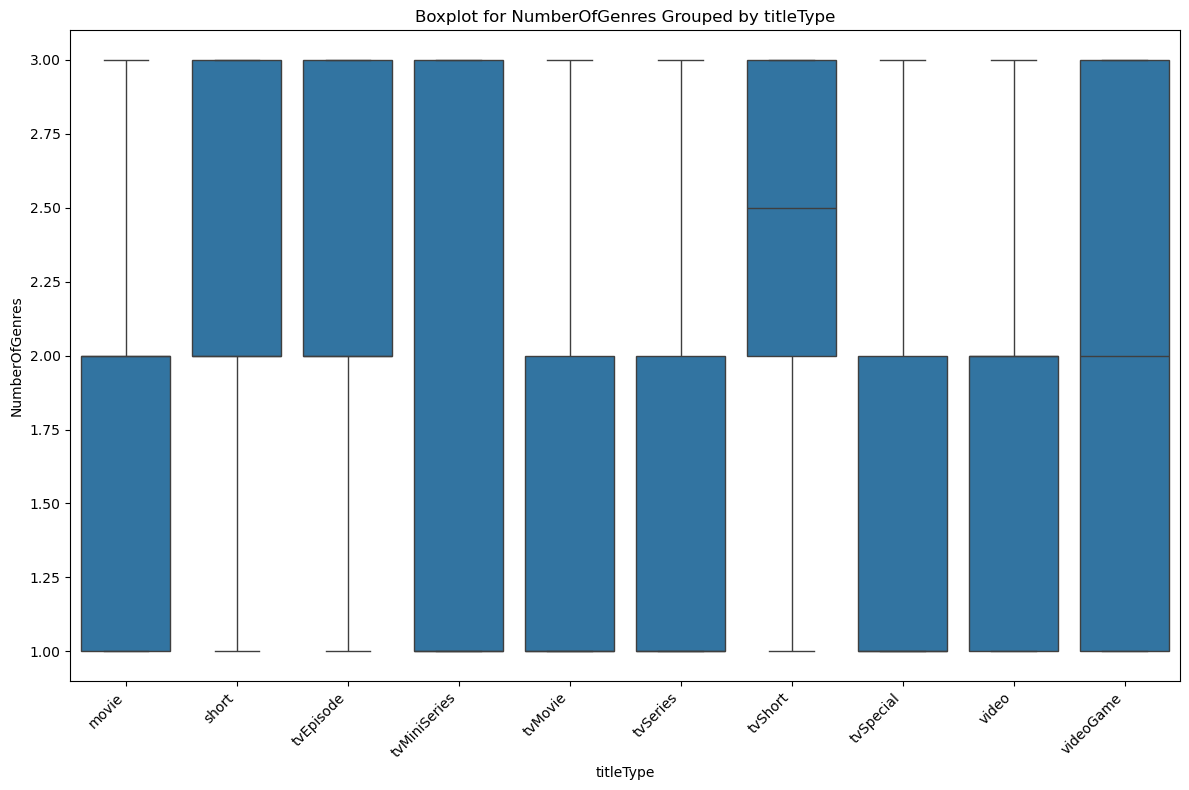

In [144]:
calculate_outliers(data_train, "NumberOfGenres")
calculate_outliers(data_train, "NumberOfGenres", group_by="titleType")


Given the results of the tests, it's drastic to reduce the dataset of almost the 50%. For this reason, outliers will not be removed.

# Correlation
Let's analyze the correlations between columns.

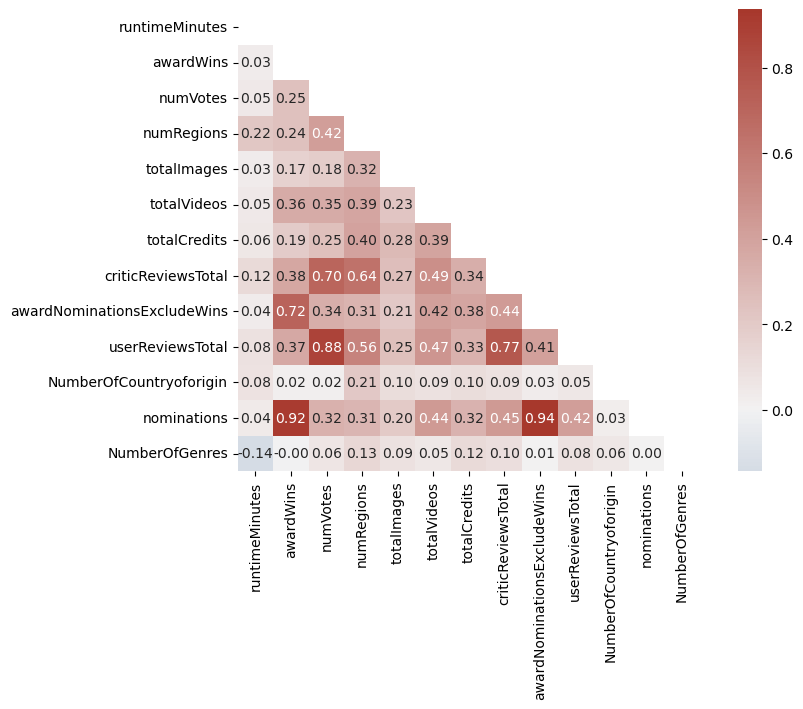

Top-10 Correlation Pairs:
                      Variable 1          Variable 2  Correlation
115  awardNominationsExcludeWins         nominations     0.936212
24                     awardWins         nominations     0.915927
35                      numVotes    userReviewsTotal     0.877057
124             userReviewsTotal  criticReviewsTotal     0.769506
105  awardNominationsExcludeWins           awardWins     0.716455
33                      numVotes  criticReviewsTotal     0.702509
46                    numRegions  criticReviewsTotal     0.637375
48                    numRegions    userReviewsTotal     0.556091
72                   totalVideos  criticReviewsTotal     0.493433
122             userReviewsTotal         totalVideos     0.465596

Last-10 Correlation Pairs:
                      Variable 1                   Variable 2  Correlation
104  awardNominationsExcludeWins               runtimeMinutes     0.038017
4                 runtimeMinutes                  totalImages     0.03

In [145]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Specify the subset of columns for which you want the correlation matrix
subset_columns = [
    "runtimeMinutes", 
    "awardWins", 
    "numVotes", 
    "numRegions", 
    "totalImages", 
    "totalVideos", 
    "totalCredits", 
    "criticReviewsTotal", 
    "awardNominationsExcludeWins", 
    "userReviewsTotal", 
    "NumberOfCountryoforigin", 
    "nominations", 
    "NumberOfGenres"
]

# Filter the DataFrame to include only the desired subset of columns
subset_int_columns = data_train[subset_columns]

# Compute the correlation matrix for the subset
corr_matrix = subset_int_columns.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(10, 6))

# Create a custom diverging palette
cmap = sns.diverging_palette(250, 15, s=75, l=40, n=9, center="light", as_cmap=True)

_ = sns.heatmap(corr_matrix, mask=mask, center=0, annot=True, fmt='.2f', square=True, cmap=cmap)
plt.show()

# Flatten the correlation matrix and reset the index to get all pairs
corr_pairs = corr_matrix.abs().unstack().reset_index()

# Rename the columns for better understanding
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']

# Remove self-correlations (correlation of a variable with itself)
corr_pairs = corr_pairs[corr_pairs['Variable 1'] != corr_pairs['Variable 2']]

# Sort by correlation value in descending order
sorted_corr_pairs = corr_pairs.sort_values(by='Correlation', ascending=False)

# Drop duplicate pairs (e.g., A-B and B-A)
sorted_corr_pairs = sorted_corr_pairs.drop_duplicates(subset=['Correlation'])

# Get the top-10 and last-10 correlation pairs
top_10_corr_pairs = sorted_corr_pairs.head(10)
last_10_corr_pairs = sorted_corr_pairs.tail(10)

# Print the results
print("Top-10 Correlation Pairs:")
print(top_10_corr_pairs)

print("\nLast-10 Correlation Pairs:")
print(last_10_corr_pairs)


numVotes and ratingCount: Correlation of 1.00, indicating these two features are likely identical or very closely related. Therefore, ratingCount will be dropped.

In [146]:
# data_train = data_train.drop(columns='ratingCount')
# data_test = data_test.drop(columns='ratingCount')

# # also from the numeric datasets
# numeric_data_train = data_train.drop(columns='ratingCount')
# numeric_data_test = numeric_data_test.drop(columns='ratingCount')

# data_train.info()


In [147]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5478 entries, 0 to 5477
Columns: 164 entries, originalTitle to startYearDecade
dtypes: bool(2), float64(3), int64(157), object(2)
memory usage: 6.8+ MB


Finally, the Normalization process. Given the fact that we kept the outliers, StandardScaler (Z-Score) is the best choice.

# Standardize

# Analisi delle Trasformazioni per Clustering

Questa analisi fornisce una panoramica sulle trasformazioni proposte per i dati, con particolare attenzione ai diversi algoritmi di clustering: **OPTICS**, **DBSCAN**, **X-Scan**, **K-Mode** e **clustering gerarchico**.

---

## Considerazioni sugli Algoritmi di Clustering

### 1. **OPTICS** e **DBSCAN**
- Entrambi si basano sulla densità locale per identificare i cluster.
- **Sensibilità alla scala**:
  - La distanza Euclidea è utilizzata come metrica, quindi le variabili devono essere scalate in modo uniforme.
- **Skewness e outlier**:
  - Gli outlier possono influenzare i risultati (ad esempio, falsi cluster).
  - La skewness può distorcere le distanze.

**Trasformazioni consigliate**:
- **Logaritmica** per variabili altamente skewed (es. `numVotes`, `awardWins`, `nominations`).
- **Min-Max Scaling** o **Standard Scaling** per uniformare le scale tra tutte le variabili.

---

### 2. **X-Scan**
- Questo algoritmo, come DBSCAN, si basa sulla densità ma può gestire cluster con forme complesse.
- Richiede input ben scalati per evitare che una variabile domini i calcoli.

**Trasformazioni consigliate**:
- Simile a DBSCAN: usa **Logaritmica** per skewness e **Min-Max Scaling** per uniformare i range.

---

### 3. **K-Mode**
- Progettato per dati categorici.
- **Le tue variabili sono numeriche**, quindi K-Mode potrebbe non essere ideale a meno di effettuare una **discretizzazione** o trasformare alcune variabili numeriche in categorie (es. binning per `runtimeMinutes`, `numVotes`).

**Trasformazioni consigliate**:
- **Binning** per alcune variabili (es. convertire `runtimeMinutes` in intervalli come [<30, 30-60, >60 minuti]).
- Evita il log-scaling o lo standard scaling: non ha senso per K-Mode che non lavora con distanze Euclidee.

---

### 4. **Clustering Gerarchico**
- Si basa sulle distanze tra coppie di punti.
- **Sensibilità alla scala**: Variabili con range ampio possono distorcere i risultati.
- **Distribuzione**: Non è particolarmente sensibile a skewness o outlier, ma è sempre meglio bilanciare i dati.

**Trasformazioni consigliate**:
- **Standard Scaling** per dati distribuiti normalmente.
- **Logaritmica** per variabili skewed.
- **Min-Max Scaling** per normalizzare i range.

---

## Proposta Globale di Trasformazioni

Ecco come normalizzare i dati per garantire che siano adatti a tutti gli algoritmi:

| **Colonna**                  | **Trasformazione consigliata**     | **Motivazione**                                                                 |
|-------------------------------|-------------------------------------|---------------------------------------------------------------------------------|
| `runtimeMinutes`              | **Standard Scaling**               | Bilancia la varianza, evita che domini le distanze.                             |
| `awardWins`                   | **Logaritmica → Min-Max Scaling**  | Gestisce skewness e outlier, rende i valori comparabili.                        |
| `numVotes`                    | **Logaritmica → Min-Max Scaling**  | Comprimi il range enorme e normalizza per densità-based clustering.             |
| `numRegions`                  | **Min-Max Scaling**                | Valori discreti e limitati, facile normalizzazione.                             |
| `totalImages`                 | **Logaritmica → Min-Max Scaling**  | Skewness elevata e valori con range ampio.                                      |
| `totalVideos`                 | **Min-Max Scaling**                | Range discreto, valori limitati, facilmente scalabili.                          |
| `totalCredits`                | **Logaritmica → Min-Max Scaling**  | Gestione degli outlier con compressione del range.                              |
| `criticReviewsTotal`          | **Standard Scaling**               | Bilancia la varianza mantenendo le relazioni relative.                          |
| `awardNominationsExcludeWins` | **Logaritmica → Min-Max Scaling**  | Skewness elevata, gestione degli outlier e scaling uniforme.                    |
| `userReviewsTotal`            | **Logaritmica → Min-Max Scaling**  | Simile a `numVotes`, alta skewness.                                             |
| `NumberOfCountryoforigin`     | **Min-Max Scaling**                | Valori discreti e range limitato (da 1 a 13).                                   |
| `nominations`                 | **Logaritmica → Min-Max Scaling**  | Gestione valori negativi con costante + logaritmica per skewness.               |
| `NumberOfGenres`              | **Min-Max Scaling**                | Valori discreti e limitati, normalizzazione semplice.                           |

---

## Motivazioni Generali per il Clustering

1. **Uniformità delle Scale**:
   - Con **Min-Max Scaling** e **Standard Scaling**, tutte le variabili hanno lo stesso range o la stessa varianza, fondamentale per DBSCAN, OPTICS, X-Scan e clustering gerarchico.

2. **Riduzione dell'Impatto degli Outlier**:
   - Le trasformazioni logaritmiche riducono l’impatto degli outlier, un problema critico per gli algoritmi basati sulla densità (OPTICS e DBSCAN).

3. **Gestione della Skewness**:
   - Molte variabili presentano distribuzioni asimmetriche.
   - Le trasformazioni proposte rendono le distribuzioni più simmetriche, migliorando le prestazioni degli algoritmi di clustering.

4. **Mantenimento delle Relazioni Relative**:
   - Min-Max Scaling e Standard Scaling preservano le relazioni relative, essenziali per clustering gerarchico e metodi basati su distanze.

5. **Flessibilità per K-Mode**:
   - Variabili come `runtimeMinutes` o `numVotes` possono essere discretizzate per adattarsi a K-Mode, mantenendo comunque il supporto per gli altri algoritmi.

---

## Implementazione del Modello Proposto

Puoi implementare questa pipeline come segue:

In [148]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import pandas as pd

def scale_dataset(data, standard_columns, minmax_columns, log_columns, minmax_range=(0, 10)):
    """
    Scales a dataset with specified transformations for groups of columns.

    Args:
        data (pd.DataFrame): The input dataset to scale.
        standard_columns (list): Columns to scale using Standard Scaling.
        minmax_columns (list): Columns to scale using Min-Max Scaling.
        log_columns (list): Columns to transform using log + Min-Max Scaling.
        minmax_range (tuple): The range for Min-Max Scaling (default: (0, 10)).

    Returns:
        pd.DataFrame: A new DataFrame with scaled columns.
    """
    # Create a copy of the dataset
    scaled_data = data.copy()

    # Standard Scaling
    if standard_columns:
        scaler_standard = StandardScaler()
        scaled_data[standard_columns] = scaler_standard.fit_transform(
            scaled_data[standard_columns]
        )

    # Min-Max Scaling
    if minmax_columns:
        scaler_minmax = MinMaxScaler(feature_range=minmax_range)
        scaled_data[minmax_columns] = scaler_minmax.fit_transform(
            scaled_data[minmax_columns]
        )

    # Log + Min-Max Scaling
    for column in log_columns:
        # Apply log1p transformation
        scaled_data[column] = np.log1p(scaled_data[column])  # Log-transform
        
        # Apply Min-Max Scaling to the log-transformed data
        scaled_data[column] = MinMaxScaler(feature_range=minmax_range).fit_transform(
            scaled_data[[column]]
        )

    return scaled_data

# Example Usage
columns_to_standard_scale = ["runtimeMinutes", "criticReviewsTotal"]
columns_to_minmax_scale = [
    "numRegions", "totalVideos", "NumberOfCountryoforigin", "NumberOfGenres"
]
columns_to_log_scale = [
    "awardWins", "numVotes", "totalImages", "totalCredits", 
    "awardNominationsExcludeWins", "userReviewsTotal", "nominations"
]

scaled_train = scale_dataset(
    data=data_train,
    standard_columns=columns_to_standard_scale,
    minmax_columns=columns_to_minmax_scale,
    log_columns=columns_to_log_scale,
    minmax_range=(0, 10)
)

scaled_test = scale_dataset(
    data=data_test,
    standard_columns=columns_to_standard_scale,
    minmax_columns=columns_to_minmax_scale,
    log_columns=columns_to_log_scale,
    minmax_range=(0, 10)
)


In [158]:
def summarize_columns(dataframe, columns):
    """
    Prints the minimum, maximum, median, and average of the specified columns in the DataFrame.

    Parameters:
    dataframe (pd.DataFrame): The DataFrame containing the data.
    columns (list): List of column names to summarize.

    Returns:
    None
    """
    summary = []
    for column in columns:
        if column in dataframe.columns:
            col_data = dataframe[column]
            if pd.api.types.is_numeric_dtype(col_data):
                summary.append({
                    "Column": column,
                    "Min": col_data.min(),
                    "Max": col_data.max(),
                    "Median": col_data.median(),
                    "avg": col_data.mean(),
                    "Std Dev": col_data.std()
                })
            else:
                print(f"Skipping non-numeric column: {column}")
        else:
            print(f"Column '{column}' not found in the DataFrame.")

In [153]:
summarize_columns(data_train, columns_to_scale)

                         Column  Min        Max  Median          avg  \
0                runtimeMinutes  1.0     1050.0    57.0    61.307777   
1                     awardWins  0.0      254.0     0.0     0.504901   
2                      numVotes  5.0  1071372.0    37.0  1524.268164   
3                    numRegions  1.0       63.0     1.0     3.593465   
4                   totalImages  0.0     2526.0     2.0    10.677620   
5                   totalVideos  0.0       83.0     0.0     0.272180   
6                  totalCredits  0.0     2482.0    35.0    60.341731   
7            criticReviewsTotal  0.0      567.0     0.0     3.105878   
8   awardNominationsExcludeWins  0.0      256.0     0.0     0.544907   
9              userReviewsTotal  0.0     2423.0     0.0     7.460570   
10      NumberOfCountryoforigin  1.0       13.0     1.0     1.094560   
11                  nominations  0.0      409.0     0.0     1.125898   
12               NumberOfGenres  1.0        3.0     2.0     1.92

In [155]:
summarize_columns(scaled_train, columns_to_scale)

                         Column       Min        Max    Median           avg  \
0                runtimeMinutes -1.358784  22.276046 -0.097058 -3.404846e-17   
1                     awardWins  0.000000  10.000000  0.000000  2.762041e-01   
2                      numVotes  0.000000  10.000000  1.526398  1.891825e+00   
3                    numRegions  0.000000  10.000000  0.000000  4.183008e-01   
4                   totalImages  0.000000  10.000000  1.402223  1.690736e+00   
5                   totalVideos  0.000000  10.000000  0.000000  3.279273e-02   
6                  totalCredits  0.000000  10.000000  4.584133  4.503832e+00   
7            criticReviewsTotal -0.168151  30.529057 -0.168151  0.000000e+00   
8   awardNominationsExcludeWins  0.000000  10.000000  0.000000  2.848178e-01   
9              userReviewsTotal  0.000000  10.000000  0.000000  9.086310e-01   
10      NumberOfCountryoforigin  0.000000  10.000000  0.000000  7.880005e-02   
11                  nominations  0.00000

In [156]:
def store_dataset(data, filename):
    
    file_path = f"{filename}.csv"
    data.to_csv(file_path, index=False)
    
    print(f"Dataset successfully stored as {file_path}")
    return file_path

test = store_dataset(data_test, 'data/output/01_data_understanding/data_train')
train = store_dataset(data_train, 'data/output/01_data_understanding/data_test')

test_scaled = store_dataset(scaled_test, 'data/output/01_data_understanding/scaled_data_train')
train_scaled = store_dataset(scaled_train, 'data/output/01_data_understanding/scaled_data_test')

Dataset successfully stored as data/output/01_data_understanding/data_train.csv
Dataset successfully stored as data/output/01_data_understanding/data_test.csv
Dataset successfully stored as data/output/01_data_understanding/scaled_data_train.csv
Dataset successfully stored as data/output/01_data_understanding/scaled_data_test.csv


1. Eliminare gli outlier e gestire i missing values in modo che vi sia la mediana come valore nuovo
4. `awardWins`, `numVotes`, `totalImages`, `totalVideos`, `totalCredits`, `criticReviewsTotal`, `awardNominationsExcludeWins`, `userReviewsTotal`, `ratingCount`, `nominations`: normalizzare ed eventualmente usare il logaritmo. Stampare media, mediana, deviazione standard prima e dopo la trasformazione.